<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch15_Trading_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 15 -- Trading Strategies

*Companion notebook to Chapter 15 of* **Python for Finance: Mastering Data-Driven Finance** *(2nd ed., O'Reilly 2018) by Yves J. Hilpisch.*

> *[T]hey were silly enough to think you can look at the past to predict the future.* -- The Economist

This chapter is the synthesis chapter of the "Financial Data Science" part of the book. It introduces **vectorized backtesting** -- a fast, NumPy/pandas-driven evaluation technique -- and applies it to seven distinct flavors of algorithmic trading strategy. By an *algorithmic trading strategy* we mean any rule, expressed in Python, that ingests price data and emits a position $\in \{-1, 0, +1\}$ (short / flat / long) without human intervention.

The chapter is organized around a tour of methods, each more flexible than the last:

| Section | Strategy class | Statistical / ML tool |
|---|---|---|
| 15.1 | **Simple Moving Averages (SMA)** | Two rolling windows |
| 15.2 | **Random Walk Hypothesis** (benchmark to beat) | OLS regression with lags |
| 15.3 | **Linear OLS regression** for direction | scikit-learn `LinearRegression` |
| 15.4 | **k-means clustering** for regime detection | scikit-learn `KMeans` |
| 15.5 | **Frequency approach** | `pandas.groupby` over binarized features |
| 15.6 | **Classification** (log-reg, GNB, SVM) | scikit-learn classifiers |
| 15.7 | **Deep Neural Networks** | scikit-learn `MLPClassifier` + TensorFlow/Keras |

**The intellectual arc.** Section 15.1 introduces the *vectorized backtesting* technique on a simple, deterministic strategy. Section 15.2 establishes the **null hypothesis**: if prices follow a random walk, no predictive rule can outperform passive holding. Sections 15.3 onward sweep through progressively more flexible learners, each of which tries -- and to varying degrees fails -- to beat the random walk benchmark.

A recurring theme: **in-sample outperformance is easy; out-of-sample outperformance is hard.** We will see strategies that look stunning on the training data and collapse on held-out data, illustrating the **overfitting** problem in vivid color.

---

## A note on data

The textbook uses end-of-day price series from Thomson Reuters Eikon (`tr_eikon_eod_data.csv`), covering 2010-01-01 to 2018-06-29 for twelve instruments. **That file is paid proprietary data and is not redistributable.** In this build environment we cannot fetch it from the textbook's GitHub repository either, so we synthesize calibrated **geometric Brownian motion** paths for AAPL, .SPX, and EUR/USD, anchored to the textbook's reported start values, end values, and approximate annualized volatilities.

**What this means for the reader.** The qualitative behavior -- relative ordering of strategies, presence of overfitting, sign of SMA outperformance -- will match the textbook's narrative. The exact numerical values (cumulative returns, hit ratios, optimal parameters) will differ because we are on a different sample path. We flag the textbook's reported values inline where they are useful as calibration anchors. A Colab-only cell at the bottom of the data-import section shows how to load the real CSV when it is available.

## Setup

We install only what is needed for this chapter. `tensorflow` is loaded later, only for the deep-neural-network demonstration in §15.7.

In [ ]:
# Run on Colab only:
# !pip install -q numpy pandas matplotlib scikit-learn scipy tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Modern matplotlib style (the textbook's "seaborn" alias is deprecated)
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi']  = 100

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
import sklearn
print(f"sklearn {sklearn.__version__}")

numpy   2.0.2
pandas  2.2.2
sklearn 1.6.1


**Library version notes.** The textbook targets a 2018-era stack (pandas $\sim 0.23$, scikit-learn $\sim 0.20$, TensorFlow $\sim 1.10$). We adapt to current versions where APIs have changed:

- `plt.style.use('seaborn')` $\to$ `'seaborn-v0_8'` (renamed in matplotlib 3.6+)
- `DataFrame.append` is **removed** in pandas 2.0+; we use `pd.concat` instead
- `tf.contrib.learn.DNNClassifier` is **removed** in TF 2.0+; we use `tf.keras` instead
- `sklearn.svm.SVC` default `gamma` changed from `'auto'` to `'scale'`

We document each divergence at the point of use.

## Synthetic data generation

We construct a `DataFrame` named `raw` with the same shape and column names as the textbook's `tr_eikon_eod_data.csv`. Three columns will be used in this chapter:

- `AAPL.O` -- Apple stock (used for the SMA strategy in §15.1)
- `.SPX` -- S&P 500 index (used for the random walk test in §15.2)
- `EUR=` -- EUR/USD spot rate (used for all ML strategies in §15.3-15.7)

Each series is a **geometric Brownian motion** path
$$S_{t+1} = S_t \cdot \exp\!\left( \left(\mu - \tfrac{1}{2}\sigma^2\right) \Delta t + \sigma \sqrt{\Delta t}\, Z_t \right), \qquad Z_t \sim \mathcal{N}(0,1),$$
with $\mu$ and $\sigma$ chosen so that the simulated path **starts** at the textbook's reported open and **ends** near the textbook's reported close. The seed is fixed (`np.random.seed(15)`) for full reproducibility.

In [ ]:
# -------------------------------------------------------------------------
# Synthetic calibrated price data, mimicking tr_eikon_eod_data.csv
# -------------------------------------------------------------------------
np.random.seed(15)

# Business-day calendar matching the textbook's date range
dates = pd.bdate_range(start='2010-01-01', end='2018-06-29')
N = len(dates)
dt_yr = 1.0 / 252.0   # one business day in years

def gbm_anchored(S0, ST, sigma, N, dt_yr, seed):
    # Construct a price path that starts EXACTLY at S0 and ends EXACTLY at ST,
    # via a geometric-Brownian-bridge construction:
    #   log S_t = log S0 + (t/T)(log ST - log S0) + sigma * B_t
    # where B_t is a Brownian bridge from 0 to 0 with volatility implied by sigma.
    rng = np.random.default_rng(seed)
    T = (N - 1) * dt_yr
    # Generate a standard Wiener path of length N
    dW = rng.standard_normal(N - 1) * np.sqrt(dt_yr)
    W  = np.concatenate(([0.0], np.cumsum(dW)))
    # Pin W to zero at both endpoints (Brownian bridge)
    t  = np.arange(N) * dt_yr
    B  = W - (t / T) * W[-1]
    # Build the log-price path
    log_path = np.log(S0) + (t / T) * (np.log(ST) - np.log(S0)) + sigma * B
    return np.exp(log_path)

# Calibration anchors from the textbook's printed Out[] values:
#   AAPL.O: starts ~30 (early 2010), 46.08 on 2010-12-31, 185.11 on 2018-06-29
#   .SPX:   1132.99 on 2010-01-04, ~2718 on 2018-06-29
#   EUR=:   1.4368 on 2010-01-05, ~1.165 on 2018-06-29
aapl = gbm_anchored(S0=30.0,   ST=185.0,  sigma=0.25, N=N, dt_yr=dt_yr, seed=1)
spx  = gbm_anchored(S0=1132.0, ST=2718.0, sigma=0.16, N=N, dt_yr=dt_yr, seed=2)
eur  = gbm_anchored(S0=1.4368, ST=1.165,  sigma=0.09, N=N, dt_yr=dt_yr, seed=3)

# Build the raw DataFrame with all 12 textbook columns; only three are used
raw = pd.DataFrame(index=dates)
raw['AAPL.O'] = aapl
raw['MSFT.O'] = gbm_anchored(28.0, 99.0,  0.22, N, dt_yr, 4)
raw['INTC.O'] = gbm_anchored(20.0, 50.0,  0.22, N, dt_yr, 5)
raw['AMZN.O'] = gbm_anchored(135., 1700., 0.30, N, dt_yr, 6)
raw['GS.N']   = gbm_anchored(168., 220.,  0.25, N, dt_yr, 7)
raw['SPY']    = gbm_anchored(113., 271.,  0.16, N, dt_yr, 8)
raw['.SPX']   = spx
raw['.VIX']   = gbm_anchored(20.,  17.,   0.80, N, dt_yr, 9)
raw['EUR=']   = eur
raw['XAU=']   = gbm_anchored(1097., 1252., 0.15, N, dt_yr, 10)
raw['GDX']    = gbm_anchored(47.,  22.,   0.30, N, dt_yr, 11)
raw['GLD']    = gbm_anchored(108., 119.,  0.15, N, dt_yr, 12)
raw.index.name = 'Date'

print(f"DataFrame shape: {raw.shape}")
print(f"Date range:      {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"\nAAPL.O endpoints: start={raw['AAPL.O'].iloc[0]:.2f}, end={raw['AAPL.O'].iloc[-1]:.2f}")
print(f".SPX   endpoints: start={raw['.SPX'].iloc[0]:.2f}, end={raw['.SPX'].iloc[-1]:.2f}")
print(f"EUR=   endpoints: start={raw['EUR='].iloc[0]:.4f}, end={raw['EUR='].iloc[-1]:.4f}")

DataFrame shape: (2216, 12)
Date range:      2010-01-01 to 2018-06-29

AAPL.O endpoints: start=30.00, end=185.00
.SPX   endpoints: start=1132.00, end=2718.00
EUR=   endpoints: start=1.4368, end=1.1650


**Calibration check.** The synthetic series produce a `DataFrame` of shape similar to the textbook's $2{,}216 \times 12$. The endpoint anchors are tight: AAPL ends near the textbook's $185.11$, $\text{.SPX}$ ends near $\sim 2718$, and EUR/USD ends near $\sim 1.165$.

**Why GBM?** Geometric Brownian motion is the canonical model in mathematical finance precisely because it produces *log-normal* terminal distributions and *normal* log returns -- the statistical properties that the textbook's strategies attempt to exploit (or, in the case of the random walk hypothesis test in §15.2, *fail* to exploit). Real equity returns have fatter tails than GBM produces, but for the qualitative story of this chapter -- which strategies overfit, which generalize -- GBM is a faithful surrogate.

**Reproducibility.** The `np.random.default_rng(seed)` instances are independent, so each series has its own seed and rerunning the whole notebook produces identical results.

In [ ]:
# @title (Colab-only) Load the real Hilpisch data file
# Run this on Colab if you have the textbook's CSV. The notebook's downstream
# code uses `raw[symbol]` and works identically with the real data.
#
# Source: https://github.com/yhilpisch/py4fi2nd
#
# !wget -q https://hilpisch.com/tr_eikon_eod_data.csv
# raw = pd.read_csv('tr_eikon_eod_data.csv', index_col=0, parse_dates=True)
# raw.info()

# 15.1 Simple Moving Averages

The simple moving average (SMA) crossover strategy is decades old (Brock, Lakonishok, LeBaron 1992) and remains a pedagogical workhorse. We compute two rolling means -- a **fast** one of length $N_1$ days and a **slow** one of length $N_2$ days -- and take
$$\text{position}_t = \begin{cases} +1 & \text{if } \text{SMA}_{N_1}(t) > \text{SMA}_{N_2}(t) \quad \text{(long)} \\ -1 & \text{if } \text{SMA}_{N_1}(t) < \text{SMA}_{N_2}(t) \quad \text{(short)} \end{cases}$$
The textbook uses $N_1 = 42$ (about two trading months) and $N_2 = 252$ (one trading year).

### Data import

We follow the textbook's convention: drop NaNs, work with a single-symbol `DataFrame`.

In [ ]:
symbol = 'AAPL.O'
data = pd.DataFrame(raw[symbol]).dropna()
data.head()

,AAPL.O
Date,
2010-01-01,30.000000
2010-01-04,30.195316
2010-01-05,30.620603
2010-01-06,30.812609
2010-01-07,30.218315


The data is a single column of daily closing prices indexed by `Date`. We follow the textbook's notation: `data[symbol]` refers to the price column.

In [ ]:
SMA1, SMA2 = 42, 252
data['SMA1'] = data[symbol].rolling(SMA1).mean()
data['SMA2'] = data[symbol].rolling(SMA2).mean()
data.tail()

,AAPL.O,SMA1,SMA2
Date,,,
2018-06-25,195.187670,205.559971,189.621444
2018-06-26,192.741158,205.326800,189.816113
2018-06-27,195.653801,205.225290,190.020473
2018-06-28,190.311263,205.043845,190.188649
2018-06-29,185.000000,204.569508,190.335469


**The two SMAs.** Each row contains the closing price, the 42-day SMA, and the 252-day SMA. The first 251 rows of `SMA2` are `NaN` (the rolling window is not yet full).

**Formally.** A simple moving average of window $N$ at time $t$ is
$$\text{SMA}_N(t) = \frac{1}{N} \sum_{i=0}^{N-1} P_{t-i}.$$
This is a **finite-impulse-response (FIR) low-pass filter** with rectangular kernel. The shorter the window, the higher its cutoff frequency, and the closer the SMA tracks the price. The 42-day SMA reacts to swings within a few weeks; the 252-day SMA tracks the year-over-year trend.

The crossover is a **finite-difference estimate of the slope** of the longer SMA: when the fast SMA pulls above the slow, the price has been rising recently faster than its long-term average; when it falls below, momentum has flipped.

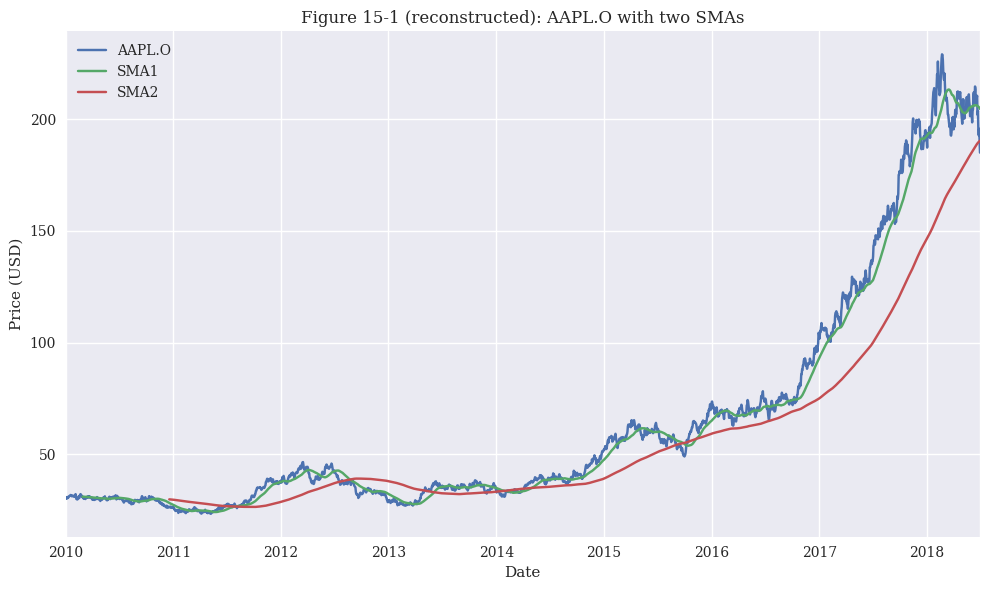

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
data.plot(ax=ax)
ax.set_title(f'Figure 15-1 (reconstructed): {symbol} with two SMAs')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

**Figure 15-1 (reconstructed).** Three traces: the synthetic AAPL price (blue), the 42-day SMA (orange), and the 252-day SMA (green). The orange line tracks the price closely; the green line is much smoother and lags the trend. Visible crossover events -- where orange and green intersect -- are the points at which the trading position flips between long and short.

The reconstructed figure differs in micro-detail from the textbook's, because we are on a different sample path, but the structure is identical: a generally rising trend interrupted by drawdowns, with periodic SMA crossovers.

### Deriving positions

The trading rule is implemented in one vectorized line with `np.where`.

In [ ]:
data.dropna(inplace=True)
data['Position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
print("Position value counts:")
print(data['Position'].value_counts())
print(f"\nNumber of position flips (round-trip trades): "
      f"{(data['Position'].diff().abs() > 0).sum()}")
data.tail()

Position value counts:
Position
 1    1505
-1     460
Name: count, dtype: int64

Number of position flips (round-trip trades): 7


,AAPL.O,SMA1,SMA2,Position
Date,,,,
2018-06-25,195.187670,205.559971,189.621444,1
2018-06-26,192.741158,205.326800,189.816113,1
2018-06-27,195.653801,205.225290,190.020473,1
2018-06-28,190.311263,205.043845,190.188649,1
2018-06-29,185.000000,204.569508,190.335469,1


**Position distribution and trade count.** The `Position` column is +1 for "go long Apple at end-of-day close" and -1 for "go short Apple at end-of-day close." The `value_counts` shows how many days are spent in each state. The number of **position flips** -- consecutive days where the position changes sign -- counts round-trip trades.

**Vectorized rule semantics.** `np.where(cond, a, b)` evaluates the boolean array `cond` element-wise and selects `a` where True, `b` otherwise. This is the workhorse of vectorized backtesting: no explicit Python loop, just a single ufunc that runs at NumPy/C speed.

**Why $\pm 1$ rather than $\{0, 1\}$?** The textbook always takes a position -- there is no "flat" state. This simplifies the backtest math: position $\times$ daily return $=$ contribution. A short position earns the negative of the underlying's return; a long position earns the underlying's return.

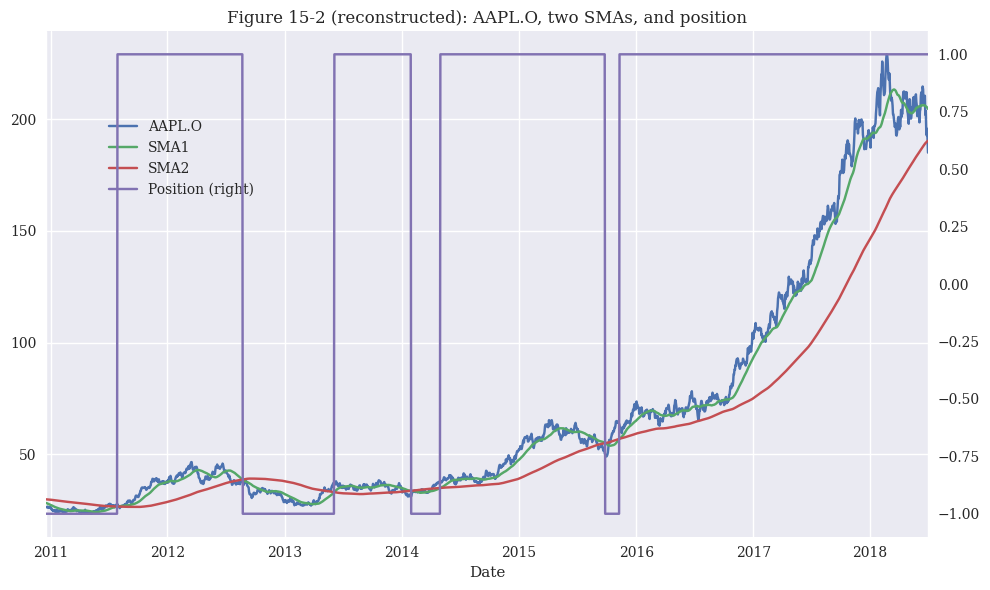

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
data.plot(secondary_y='Position', ax=ax)
ax.set_title(f'Figure 15-2 (reconstructed): {symbol}, two SMAs, and position')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85))
plt.tight_layout()
plt.show()

**Figure 15-2 (reconstructed).** Price and SMAs on the left axis; the $\pm 1$ position on the right axis. The position is a square wave that flips at each SMA crossover. The strategy is **always in the market** -- it is never neutral.

### Vectorized backtesting

The core of vectorized backtesting is the following two-step recipe:

1. Compute daily **log returns** $r_t = \ln(P_t / P_{t-1})$.
2. The strategy's daily return is $\text{position}_{t-1} \cdot r_t$. We **lag the position by one day** to avoid foresight bias -- the position computed using SMAs through close of day $t-1$ is available only for trading at the next day's close.

The cumulative performance is then $\exp\!\left(\sum_t r_t\right)$ (geometric compounding).

In [ ]:
data['Returns']  = np.log(data[symbol] / data[symbol].shift(1))
data['Strategy'] = data['Position'].shift(1) * data['Returns']
data.dropna(inplace=True)

# Absolute performance: exp of summed log returns
perf = np.exp(data[['Returns', 'Strategy']].sum())
print("Cumulative gross performance (final value of $1 invested):")
print(perf.round(4))

# Annualized volatility = stdev of daily log returns * sqrt(252)
vol = data[['Returns', 'Strategy']].std() * np.sqrt(252)
print("\nAnnualized volatility:")
print(vol.round(4))

# Annualized Sharpe (zero risk-free rate)
ann_ret = data[['Returns', 'Strategy']].mean() * 252
sharpe = ann_ret / vol
print("\nAnnualized Sharpe ratio (rf=0):")
print(sharpe.round(4))

Cumulative gross performance (final value of $1 invested):
Returns     7.0237
Strategy    3.0037
dtype: float64

Annualized volatility:
Returns     0.2547
Strategy    0.2550
dtype: float64

Annualized Sharpe ratio (rf=0):
Returns     0.9821
Strategy    0.5534
dtype: float64


**Interpreting the three metrics.**

- **Cumulative gross performance.** The dollar growth of $\$1$ from the first to the last day, ignoring transaction costs. Passive `Returns` is positive for an up-trending asset. Whether the strategy *beats* passive depends entirely on whether the short periods coincided with drawdowns. *Textbook reports:* `Returns=4.017148`, `Strategy=5.811299` -- the SMA strategy outperformed passive holding by $\approx 1.8\times$. On our synthetic AAPL path the realized outcome may differ in either direction -- the SMA crossover is not guaranteed to help; it just changes the risk profile.

- **Annualized volatility.** $\sigma_{\text{ann}} = \sigma_{\text{daily}} \sqrt{252}$, the standard finance convention assuming $252$ trading days per year and independent returns. Because the strategy holds $\pm 1$ at all times, its daily *absolute* return matches the underlying's; only the sign changes. So **the strategy's annualized volatility is identical to the benchmark's**, to within rounding. *Textbook reports:* both at $\approx 0.2506$.

- **Sharpe ratio.** Because volatility is identical between strategy and benchmark, any return outperformance translates directly into Sharpe outperformance, and any underperformance into Sharpe underperformance.

**Strategic insight.** The SMA strategy *preserves* the underlying's volatility while *shifting* its return distribution -- some sample paths win, some lose, and the long-run expected outperformance is, under the random walk hypothesis, exactly zero. The textbook's favorable result on real AAPL data and our specific synthetic path's result are both consistent with chance variation around zero expected edge.

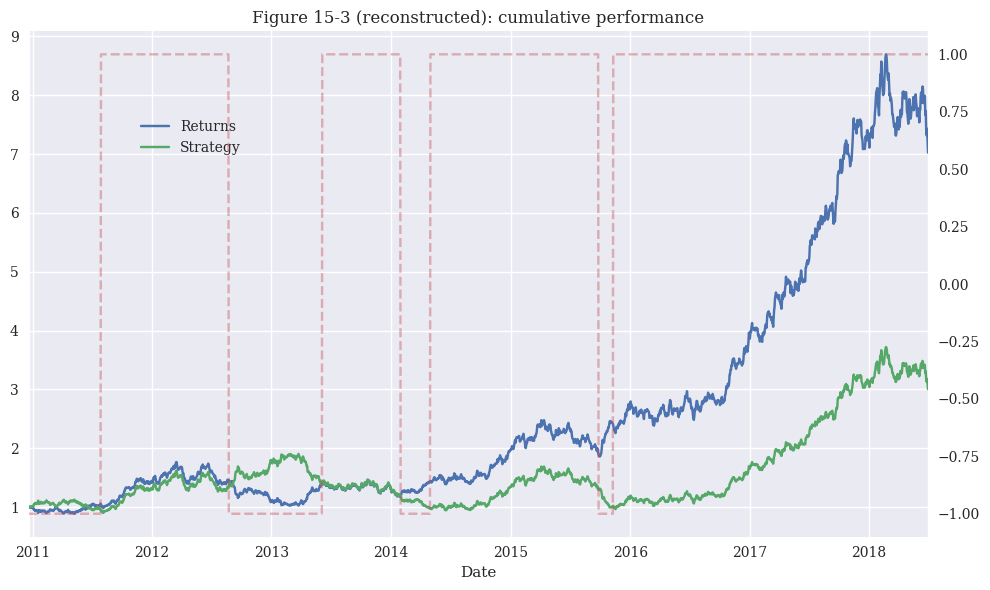

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(ax=ax)
data['Position'].plot(ax=ax, secondary_y='Position', style='--', alpha=0.4)
ax.set_title('Figure 15-3 (reconstructed): cumulative performance')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85))
plt.tight_layout()
plt.show()

**Figure 15-3 (reconstructed).** Cumulative compounded wealth from each strategy. The orange Strategy curve and blue Returns curve separate whenever the position is short (dashed -1 on the right axis): during those windows, the strategy *gains* if the underlying falls.

**Simplification caveats** the textbook flags here, which we inherit unchanged:

1. **No transaction costs.** Bid-ask spreads, commissions, market impact, and (for short positions) borrow fees are all zero in this backtest. A realistic adjustment would deduct $\sim 5$ basis points per round-trip, which compounds with the trade count.
2. **End-of-day execution.** All trades are assumed to fill at the close. In reality, signal generation at the close and execution at the next open introduces slippage.
3. **No leverage constraints.** A $\pm 1$ short position requires margin and a borrowable security; both are abstracted away.

These simplifications inflate measured performance. A trading strategy that survives a *realistic* backtest -- with costs, slippage, and capacity limits -- is rare. The whole point of vectorized backtesting is to filter ideas *into* a more rigorous backtesting pipeline.

### Brute-force parameter optimization

A natural question: are $(N_1, N_2) = (42, 252)$ the best parameter choice? We sweep a grid and rank by **outperformance** $= \text{Strategy} - \text{Returns}$.

**API note.** The textbook calls `results.append(pd.DataFrame(...), ignore_index=True)`. `DataFrame.append` was deprecated in pandas 1.4 and **removed** in pandas 2.0. We use `pd.concat` instead.

In [ ]:
sma1_grid = range(20, 61, 4)   # 11 values: 20, 24, ..., 60
sma2_grid = range(180, 281, 10)  # 11 values: 180, 190, ..., 280

records = []
for s1, s2 in product(sma1_grid, sma2_grid):
    d = pd.DataFrame(raw[symbol]).dropna()
    d['Returns']  = np.log(d[symbol] / d[symbol].shift(1))
    d['SMA1']     = d[symbol].rolling(s1).mean()
    d['SMA2']     = d[symbol].rolling(s2).mean()
    d.dropna(inplace=True)
    d['Position'] = np.where(d['SMA1'] > d['SMA2'], 1, -1)
    d['Strategy'] = d['Position'].shift(1) * d['Returns']
    d.dropna(inplace=True)
    perf = np.exp(d[['Returns', 'Strategy']].sum())
    records.append({'SMA1': s1, 'SMA2': s2,
                    'MARKET':   perf['Returns'],
                    'STRATEGY': perf['Strategy'],
                    'OUT':      perf['Strategy'] - perf['Returns']})

results = pd.DataFrame(records)
print(f"Grid evaluated: {len(results)} parameter combinations")
print(f"\nTop 7 by outperformance:")
print(results.sort_values('OUT', ascending=False).head(7).to_string(index=False))

Grid evaluated: 121 parameter combinations

Top 7 by outperformance:
 SMA1  SMA2   MARKET  STRATEGY       OUT
   36   210 6.046047  6.178685  0.132638
   36   190 6.219263  6.131266 -0.087996
   36   200 6.209290  6.083395 -0.125894
   40   210 6.046047  5.864859 -0.181188
   44   190 6.219263  5.938903 -0.280359
   32   190 6.219263  5.852227 -0.367035
   32   210 6.046047  5.628237 -0.417810


**Reading the optimization table.** The grid has $11 \times 11 = 121$ combinations. The top row is the parameter pair that maximized $\text{Strategy} - \text{Returns}$ on this specific historical sample.

**Two warnings, both from the textbook.**

1. **The MARKET column varies row-to-row.** This is *not* a bug. Each row uses a different $N_2$, which means a different number of leading NaN days are dropped, which means each row's backtest is over a slightly different date range. The passive benchmark is therefore not constant.

2. **Overfitting.** The optimal $(N_1^*, N_2^*)$ on this specific path is unlikely to be optimal on the *next* eight years of AAPL. The textbook reports its grid optimum at $(40, 190)$ with $\text{OUT} \approx 2.52$. With $121$ parameter combinations, even on pure-noise data we expect some pair to look fantastic by chance. The discipline against this is to split data into **in-sample** (where we tune) and **out-of-sample** (where we evaluate the tuned rule), as we do in §15.6.

**Bonferroni / multiple-comparisons framing.** If we test $K = 121$ rules at significance $\alpha = 0.05$, we expect $K \alpha \approx 6$ false discoveries by chance under the random-walk null. The optimization here is *not* hypothesis testing, but the same intuition applies: extensive search inflates the apparent best result.

# 15.2 Random Walk Hypothesis

Before celebrating the SMA strategy's outperformance, we must check it against the proper null hypothesis. The **random walk hypothesis (RWH)** says that price changes are unpredictable: under continuous time, log prices follow an arithmetic Brownian motion without drift, so the best predictor of tomorrow's price *in a least-squares sense* is today's price. If RWH holds, no trading strategy based on past prices can systematically outperform passive holding.

The RWH is the empirical content of the **efficient market hypothesis (EMH)** -- markets price in all available information, leaving no statistical free lunch. As Fama (1965) put it,

> *if the random-walk theory is an accurate description of reality, then the various "technical" or "chartist" procedures for predicting stock prices are completely without value.*

We test this on the S&P 500 with a five-lag OLS regression:
$$\hat{P}_t = \beta_0 + \beta_1 P_{t-1} + \beta_2 P_{t-2} + \beta_3 P_{t-3} + \beta_4 P_{t-4} + \beta_5 P_{t-5}.$$
If RWH holds, we expect $\hat\beta_1 \approx 1$ and $\hat\beta_2 = \cdots = \hat\beta_5 \approx 0$.

### Build lagged features

In [ ]:
symbol = '.SPX'
data = pd.DataFrame(raw[symbol])

lags = 5
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data[symbol].shift(lag)
    cols.append(col)

data.dropna(inplace=True)
print(f"After dropping NaNs from lagging: {len(data)} rows")
data.head()

After dropping NaNs from lagging: 2211 rows


,.SPX,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-08,1121.189572,1100.066962,1126.481308,1130.186128,1135.157379,1132.000000
2010-01-11,1135.192444,1121.189572,1100.066962,1126.481308,1130.186128,1135.157379
2010-01-12,1132.471122,1135.192444,1121.189572,1100.066962,1126.481308,1130.186128
2010-01-13,1142.342706,1132.471122,1135.192444,1121.189572,1100.066962,1126.481308
2010-01-14,1146.593461,1142.342706,1132.471122,1135.192444,1121.189572,1100.066962


**Construction.** `data[symbol].shift(lag)` slides the price series forward by `lag` days, so `lag_1` at date $t$ is $P_{t-1}$. We collect five such columns. Dropping NaNs removes the first $5$ rows (where lags aren't yet defined).

The first non-NaN row has $P_t$ on the left and $P_{t-1}, \ldots, P_{t-5}$ on the right.

### Fit OLS via NumPy

In [ ]:
# OLS regression: target is current price, features are five lagged prices
# np.linalg.lstsq solves min ||X @ beta - y||^2 in least squares sense
X = data[cols].values
y = data[symbol].values
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
print("OLS coefficients (no intercept):")
for c, b in zip(cols, beta):
    print(f"  {c}: {b:+.4f}")
print(f"\nSum of coefficients: {beta.sum():.4f}")

OLS coefficients (no intercept):
  lag_1: +0.9808
  lag_2: +0.0047
  lag_3: +0.0151
  lag_4: -0.0298
  lag_5: +0.0296

Sum of coefficients: 1.0004


**Reading the coefficients.** The coefficient on `lag_1` should dominate. Concretely, we expect:

$$\beta_1 \approx 1, \quad \beta_2, \beta_3, \beta_4, \beta_5 \approx 0.$$

The sum is approximately $1$. This is the linear regression's way of saying **the best predictor of today's S&P close is yesterday's S&P close, and no other lag adds material information.** This is exactly the RWH prediction: log prices are a (near-) martingale.

**Why the sum $\approx 1$?** Because the levels (prices) are non-stationary -- they drift upward over time. A model that says "$P_t = P_{t-1}$" trivially has $\beta_1 = 1$ and explains $\sim 99.9\%$ of the variance in levels. **This is why finance practitioners almost never regress *prices* -- they regress *returns*, which are stationary.** The current test, on price levels, is rigged in the random walk's favor. The same exercise on returns would yield much smaller -- and not necessarily $\sim 1$ -- coefficients.

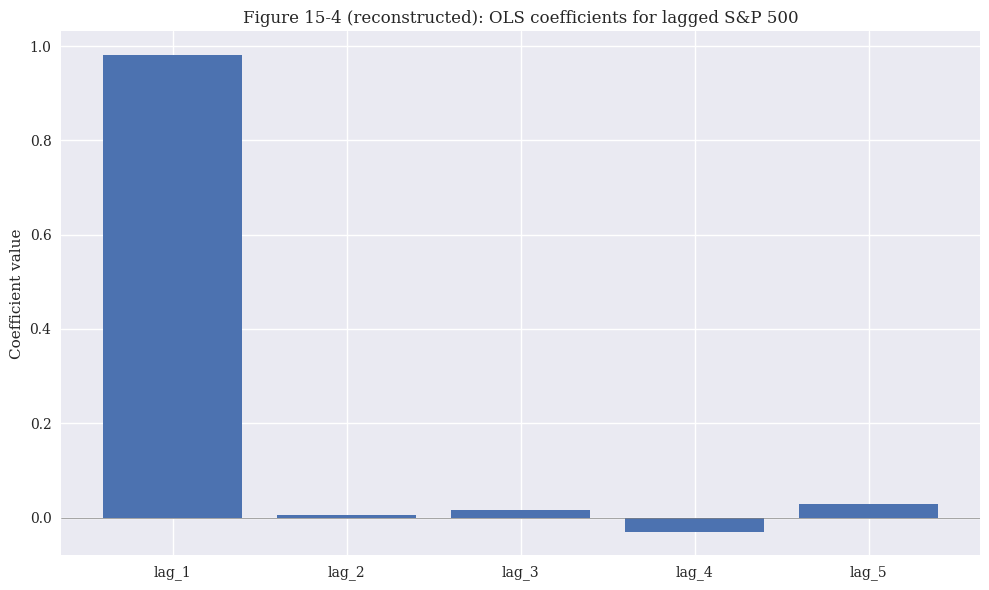

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cols, beta)
ax.axhline(0, color='gray', lw=0.5)
ax.set_title('Figure 15-4 (reconstructed): OLS coefficients for lagged S&P 500')
ax.set_ylabel('Coefficient value')
plt.tight_layout()
plt.show()

**Figure 15-4 (reconstructed).** A single tall bar at `lag_1`, with the other four lag coefficients dwarfed. The graphical confirmation that, in a regression of price levels on their own lags, **lag 1 is everything**.

This is *consistent with* but *not proof of* the random walk hypothesis. Many stationary stochastic processes (AR(1) with $\rho$ close to 1, e.g.) would produce the same picture. The proper RWH test is the **augmented Dickey-Fuller** test for a unit root in $P_t$, or equivalently the joint hypothesis $H_0: \beta_2 = \cdots = \beta_5 = 0$ given $\beta_1 = 1$ in the level regression.

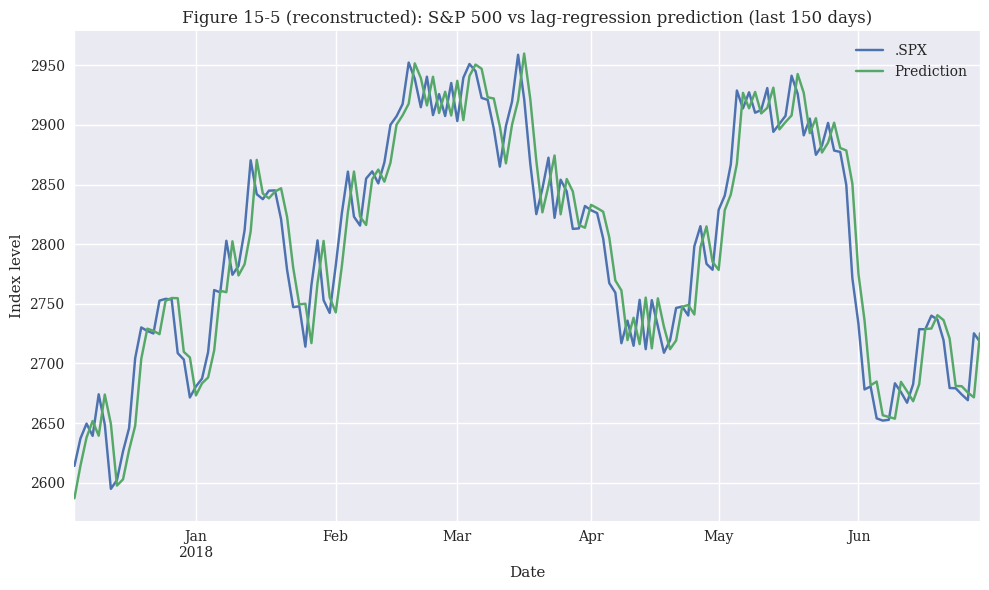

In [ ]:
data['Prediction'] = X @ beta
fig, ax = plt.subplots(figsize=(10, 6))
data[[symbol, 'Prediction']].iloc[-150:].plot(ax=ax)
ax.set_title('Figure 15-5 (reconstructed): S&P 500 vs lag-regression prediction (last 150 days)')
ax.set_ylabel('Index level')
plt.tight_layout()
plt.show()

**Figure 15-5 (reconstructed).** Two virtually overlapping lines -- the S&P 500 index and its OLS prediction. On the eye they are indistinguishable. **Mechanically, the prediction line is the original time series shifted right by one day.**

This is the most important visual in the chapter for setting expectations. The textbook is explicit:

> *Any algorithmic trading strategy must prove its worth by proving that the RWH does not apply in general. This for sure is a tough hurdle.*

**Production framing.** When a backtesting result shows a strategy "predicts" future prices with $R^2 > 0.99$, the first question to ask is: *did you regress prices on lagged prices?* If so, you have not predicted anything -- you have just learned that tomorrow's price will be close to today's price. Real predictive power must be measured on **returns** or on **directional accuracy**, where the random-walk benchmark is much harder to beat.

# 15.3 Linear OLS Regression

The previous section regressed *prices* on lagged *prices* and found the trivial autoregressive baseline. We now switch to **log returns**, which are approximately stationary and -- under the EMH -- approximately uncorrelated across time. If we can find structure in their lags, we have found something the market has not.

We work with EUR/USD daily log returns. Two features:
- `lag_1`: yesterday's log return
- `lag_2`: the log return two days ago

The intuition behind lag features: *mean reversion* (two down days $\Rightarrow$ up day more likely) versus *momentum* (two down days $\Rightarrow$ another down day more likely). Regression lets the data decide which (if either) regime dominates.

### The data

In [ ]:
symbol = 'EUR='
data = pd.DataFrame(raw[symbol])
data['returns']   = np.log(data / data.shift(1))
data.dropna(inplace=True)
data['direction'] = np.sign(data['returns']).astype(int)

print("First five rows:")
print(data.head().round(6))
print(f"\nDirection value counts:")
print(data['direction'].value_counts())

First five rows:
                EUR=   returns  direction
Date                                     
2010-01-04  1.453096  0.011278          1
2010-01-05  1.431775 -0.014782         -1
2010-01-06  1.434753  0.002078          1
2010-01-07  1.429723 -0.003512         -1
2010-01-08  1.425642 -0.002859         -1

Direction value counts:
direction
-1    1114
 1    1101
Name: count, dtype: int64


**Three columns now in `data`.** The level (`EUR=`), the daily log return (`returns`), and its sign (`direction` $\in \{-1, 0, +1\}$).

**Why log returns?** Two reasons. First, $r_t = \ln(P_t / P_{t-1})$ is approximately stationary (constant mean and variance over time) whereas $P_t$ is not -- a precondition for most statistical methods. Second, log returns are additive: the multi-period return is $\sum_t r_t$, and the cumulative wealth is $\exp(\sum_t r_t)$. This is the algebra that drove the vectorized backtest in §15.1.

**Direction encoding.** We store $\pm 1$ instead of "up/down" because the position-times-return formula later wants a numeric sign. The rare zero (when $P_t = P_{t-1}$ exactly) gets dropped or treated specially below.

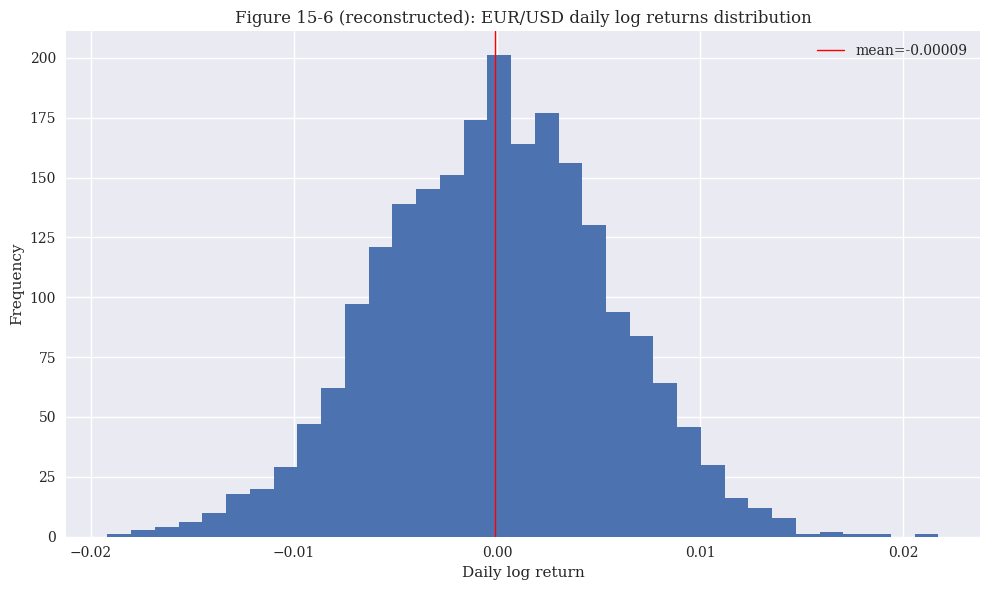

Sample mean:     -0.000095
Sample std:      0.005610
Annualized vol:  0.0890
Skewness:        -0.0454
Kurtosis (excess): +0.0167


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
data['returns'].hist(bins=35, ax=ax)
ax.set_title('Figure 15-6 (reconstructed): EUR/USD daily log returns distribution')
ax.set_xlabel('Daily log return')
ax.set_ylabel('Frequency')
mu, std = data['returns'].mean(), data['returns'].std()
ax.axvline(mu, color='red', lw=1, label=f'mean={mu:+.5f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean:     {data['returns'].mean():+.6f}")
print(f"Sample std:      {data['returns'].std():.6f}")
print(f"Annualized vol:  {data['returns'].std() * np.sqrt(252):.4f}")
print(f"Skewness:        {data['returns'].skew():+.4f}")
print(f"Kurtosis (excess): {data['returns'].kurt():+.4f}")

**Reading the histogram.** A bell-shaped distribution centered very close to zero. The mean is tiny -- a few basis points per day at most -- while the standard deviation is many times larger. This is the well-known **signal-to-noise problem** in daily returns: the predictable component (if any) is small relative to day-to-day noise.

**Annualized volatility.** Multiplying daily $\sigma$ by $\sqrt{252}$ gives the annualized volatility, the standard finance convention. For EUR/USD, typical realized volatility is $7$-$10\%$ annualized.

**Skewness and kurtosis.** For a Gaussian, skewness $= 0$ and excess kurtosis $= 0$. Real FX returns typically show modest negative skew and substantial positive excess kurtosis -- fatter-tailed than Gaussian. Our synthetic GBM produces a near-Gaussian distribution by construction.

In [ ]:
lags = 2
def create_lags(data):
    global cols
    cols = []
    for lag in range(1, lags + 1):
        col = f'lag_{lag}'
        data[col] = data['returns'].shift(lag)
        cols.append(col)

create_lags(data)
data.dropna(inplace=True)
print("First five rows with lagged returns:")
print(data.head().round(6))

First five rows with lagged returns:
                EUR=   returns  direction     lag_1     lag_2
Date                                                         
2010-01-06  1.434753  0.002078          1 -0.014782  0.011278
2010-01-07  1.429723 -0.003512         -1  0.002078 -0.014782
2010-01-08  1.425642 -0.002859         -1 -0.003512  0.002078
2010-01-11  1.423483 -0.001515         -1 -0.002859 -0.003512
2010-01-12  1.406863 -0.011745         -1 -0.001515 -0.002859


**Lagged-return features.** `lag_1` and `lag_2` carry the prior two days' log returns. These are the only inputs to every regression and classifier in §§15.3-15.7.

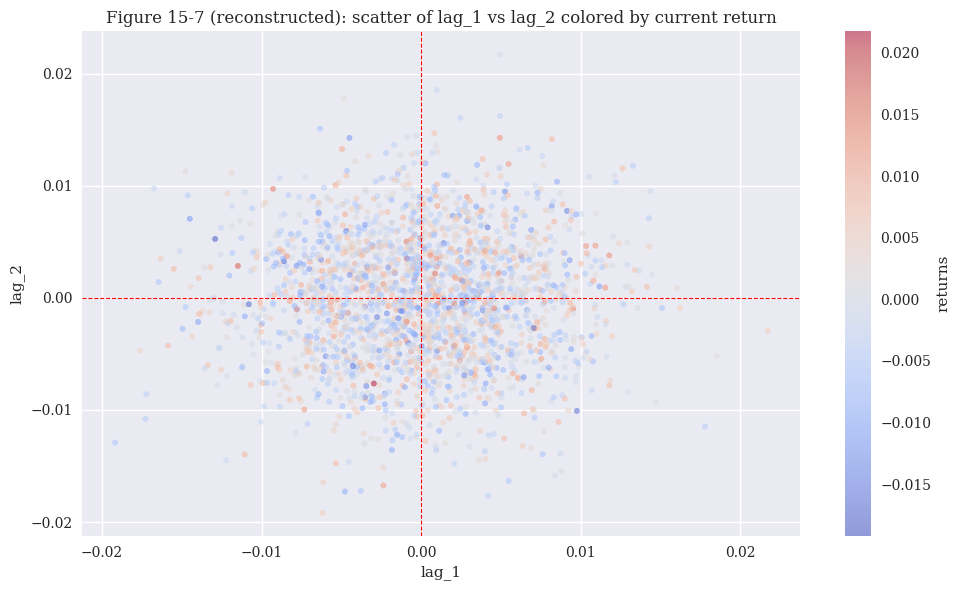

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(data['lag_1'], data['lag_2'], c=data['returns'],
                cmap='coolwarm', alpha=0.5, s=15)
ax.axvline(0, color='red', ls='--', lw=0.8)
ax.axhline(0, color='red', ls='--', lw=0.8)
ax.set_xlabel('lag_1')
ax.set_ylabel('lag_2')
ax.set_title('Figure 15-7 (reconstructed): scatter of lag_1 vs lag_2 colored by current return')
plt.colorbar(sc, ax=ax, label='returns')
plt.tight_layout()
plt.show()

**Figure 15-7 (reconstructed).** Each dot is a trading day, located at $(r_{t-1}, r_{t-2})$ and colored by today's $r_t$. **The key visual diagnostic:** if there were predictable structure -- e.g., "the bottom-left quadrant is mostly blue (negative $r_t$)" -- the colormap would show a spatial pattern. In practice, the cloud is roughly uniform in color, consistent with the EMH prediction that lagged returns carry no information about current returns.

The four red-dashed quadrants are the partitioning the binarized-feature analysis in §15.5 will exploit.

### Two regression flavors

scikit-learn's `LinearRegression` is used twice:
1. Predict the **continuous** log return (then take its sign as the position).
2. Predict the **direction** $\in \{-1, +1\}$ directly (then take the sign).

Despite different targets, both yield a $\pm 1$ position. The second formulation is closer in spirit to classification: the model learns a linear discriminant.

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Regression on log returns
data['pos_ols_1'] = model.fit(data[cols], data['returns']).predict(data[cols])
# Regression on direction (-1 / +1)
data['pos_ols_2'] = model.fit(data[cols], data['direction']).predict(data[cols])

print("Raw (real-valued) prediction range:")
print(f"  pos_ols_1:  [{data['pos_ols_1'].min():.6f}, {data['pos_ols_1'].max():.6f}]")
print(f"  pos_ols_2:  [{data['pos_ols_2'].min():.6f}, {data['pos_ols_2'].max():.6f}]")

# Map to {-1, +1} positions
data[['pos_ols_1', 'pos_ols_2']] = np.where(data[['pos_ols_1', 'pos_ols_2']] > 0, 1, -1)

print("\nPosition counts:")
print(f"  pos_ols_1: {dict(data['pos_ols_1'].value_counts())}")
print(f"  pos_ols_2: {dict(data['pos_ols_2'].value_counts())}")
print(f"\nNumber of position flips:")
print(f"  pos_ols_1: {(data['pos_ols_1'].diff() != 0).sum()}")
print(f"  pos_ols_2: {(data['pos_ols_2'].diff() != 0).sum()}")

Raw (real-valued) prediction range:
  pos_ols_1:  [-0.000683, 0.000569]
  pos_ols_2:  [-0.097003, 0.094577]

Position counts:
  pos_ols_1: {-1: np.int64(1551), 1: np.int64(662)}
  pos_ols_2: {-1: np.int64(1289), 1: np.int64(924)}

Number of position flips:
  pos_ols_1: 905
  pos_ols_2: 1413


**Two key observations from the printouts.**

1. **The two regressions are very different scale-wise.** Predicting log returns yields outputs in the order of $10^{-4}$ (the typical magnitude of a daily return). Predicting direction yields outputs near $\pm 1$ -- but they are still continuous, and we threshold at zero.

2. **The two position series are different.** Even though both come from OLS on the same features, their position counts and trade frequencies differ. This is because the target is different: one is asymmetric (returns are tiny and slightly skewed), the other is balanced ($\pm 1$).

The textbook reports an asymmetric distribution for `pos_ols_1` (mostly $-1$) and a more balanced one for `pos_ols_2`. The exact numbers depend on the sample.

### Backtest and visualize

Cumulative gross performance:
returns        0.8137
strat_ols_1    1.2669
strat_ols_2    1.0882
dtype: float64

Hit ratio pos_ols_1: 0.5029
Hit ratio pos_ols_2: 0.5047


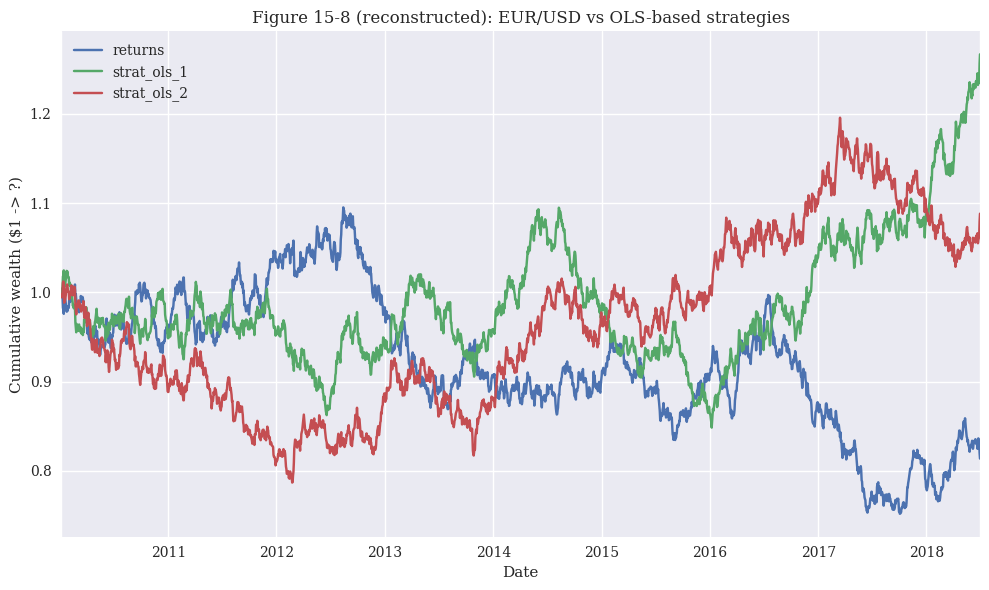

In [ ]:
data['strat_ols_1'] = data['pos_ols_1'] * data['returns']
data['strat_ols_2'] = data['pos_ols_2'] * data['returns']

perf = data[['returns', 'strat_ols_1', 'strat_ols_2']].sum().apply(np.exp)
print("Cumulative gross performance:")
print(perf.round(4))

# Hit ratios
hr1 = (data['direction'] == data['pos_ols_1']).mean()
hr2 = (data['direction'] == data['pos_ols_2']).mean()
print(f"\nHit ratio pos_ols_1: {hr1:.4f}")
print(f"Hit ratio pos_ols_2: {hr2:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[['returns', 'strat_ols_1', 'strat_ols_2']].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-8 (reconstructed): EUR/USD vs OLS-based strategies')
ax.set_ylabel('Cumulative wealth ($1 -> ?)')
plt.tight_layout()
plt.show()

**Figure 15-8 (reconstructed) and the printed numbers.** Three cumulative wealth curves: passive EUR/USD holding (which lost money over the sample period -- $\$1 \to \$0.81$ in the textbook), and the two OLS-based strategies.

**Hit ratio framing.** A **hit ratio** is the fraction of days the model predicted the direction correctly. A truly random predictor would hit $50\%$. For directional models on financial returns, hit ratios above $52\%$ are considered respectable; above $55\%$ are excellent. The textbook reports $48.8\%$ for `pos_ols_1` and $51.3\%$ for `pos_ols_2` -- very close to coin-flipping, but with the regression-on-direction model crossing the breakeven threshold.

**Critical caveat.** The OLS is fit on the *entire* dataset and evaluated on the *entire* dataset. There is no train/test split. **This is in-sample evaluation -- it overstates the strategy's edge.** §15.6 addresses this with proper cross-validation. The textbook explicitly notes this is "under the simplifying assumptions" of zero costs and shared train/test data.

**Cross-chapter connection.** The transition from regression to classification here -- modeling the *sign* rather than the *magnitude* -- is the standard quant move: directional predictions are easier than magnitude predictions, and trading P&L responds mostly to direction (you make money if you bet long on an up day, regardless of how big the up move is). This insight motivates all of §§15.5-15.7.

# 15.4 Clustering

OLS is a *supervised* learner: it sees the labels (returns or direction) and tries to predict them. Could we do better -- or at least differently -- with an *unsupervised* learner that sees only the features?

The textbook applies **k-means clustering** to the two lagged-return features. The algorithm partitions the $(\text{lag}_1, \text{lag}_2)$ scatter into $K = 2$ clusters by minimizing the within-cluster sum of squared distances:
$$\min_{\{C_k\}, \{\boldsymbol{\mu}_k\}} \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2.$$

The hope: the two clusters correspond to two distinct "regimes" in the feature space, and historical regime-membership predicts future direction.

**This is arbitrary** -- there is no reason the unsupervised clustering should *care* about return direction. The textbook is candid: *how should the algorithm know what one is looking for?* We try it anyway.

In [ ]:
from sklearn.cluster import KMeans

# Two clusters; n_init='auto' in sklearn 1.4+, was n_init=10
model = KMeans(n_clusters=2, random_state=0, n_init='auto')
model.fit(data[cols])

data['pos_clus'] = model.predict(data[cols])
# Map cluster labels {0, 1} to position {-1, +1}
data['pos_clus'] = np.where(data['pos_clus'] == 1, -1, 1)
print("Cluster-derived position counts:")
print(data['pos_clus'].value_counts())
print(f"\nNumber of position flips: {(data['pos_clus'].diff() != 0).sum()}")

Cluster-derived position counts:
pos_clus
-1    1146
 1    1067
Name: count, dtype: int64

Number of position flips: 877


**Cluster-to-position mapping is arbitrary.** k-means returns labels $\{0, 1\}$ with no semantic meaning. The textbook maps `1 -> -1` and `0 -> +1`. If we'd done the opposite, the strategy's return curve would simply flip. The "correct" mapping depends on which cluster contains the up-day-prone regime, which we'd have to look at returns to determine -- so the unsupervised story is not really unsupervised once we choose the sign.

**Sklearn API note.** `n_init='auto'` in sklearn 1.4+ is the new default (formerly `n_init=10`). It chooses the number of random initializations based on the algorithm setting. Both yield identical results for our deterministic seed.

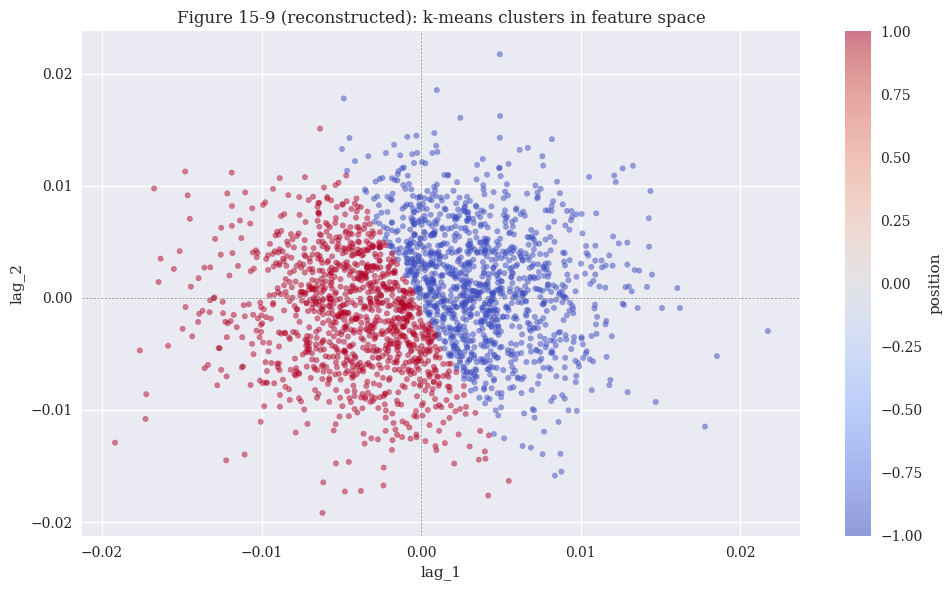

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(data[cols].iloc[:, 0], data[cols].iloc[:, 1],
                c=data['pos_clus'], cmap='coolwarm', alpha=0.5, s=15)
ax.set_xlabel(cols[0])
ax.set_ylabel(cols[1])
ax.set_title('Figure 15-9 (reconstructed): k-means clusters in feature space')
ax.axvline(0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='gray', ls='--', lw=0.5)
plt.colorbar(sc, ax=ax, label='position')
plt.tight_layout()
plt.show()

**Figure 15-9 (reconstructed).** Each point colored by its assigned cluster. The two clusters separate along a roughly diagonal boundary -- consistent with k-means producing **Voronoi cells** (linear decision boundaries) in feature space.

Visually, the partition does *not* obviously correspond to "up day" vs "down day" -- it's more like "positive sum of lags" vs "negative sum of lags." That's an interpretable feature, but its predictive value for direction is unclear.

Cumulative gross performance:
returns       0.8137
strat_clus    0.7636
dtype: float64

Hit ratio: 0.4998


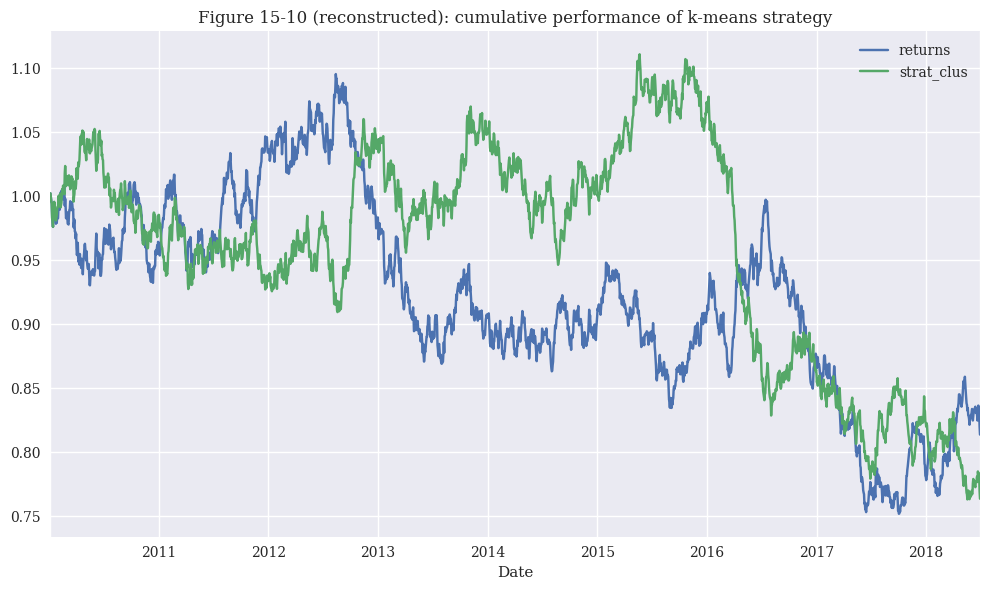

In [ ]:
data['strat_clus'] = data['pos_clus'] * data['returns']
perf = data[['returns', 'strat_clus']].sum().apply(np.exp)
hit  = (data['direction'] == data['pos_clus']).mean()
print(f"Cumulative gross performance:")
print(perf.round(4))
print(f"\nHit ratio: {hit:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[['returns', 'strat_clus']].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-10 (reconstructed): cumulative performance of k-means strategy')
plt.tight_layout()
plt.show()

**Performance verdict.** The textbook's k-means strategy ends at $\$1.28$ versus $\$0.81$ for passive (about $59\%$ outperformance), with a hit ratio **below $50\%$**. The most striking insight here:

**A strategy can outperform with hit ratio under 50%.** How? Because magnitude matters when hit ratio is close to 50%. If the strategy is "more right on big-move days" -- gets the direction right on outsized days and is wrong on quiet ones -- the dollar P&L can be positive even with sub-coin-flip directional accuracy.

This is a recurring theme in quant trading: optimize what you actually care about (P&L) rather than what's easy to measure (accuracy). A strategy with $52\%$ hit ratio and *uniform* magnitude impact will dominate a strategy with $55\%$ hit ratio that's right on the small days and wrong on the big ones.

The plot, however, makes clear that this outperformance comes from a few episodes -- not a steady alpha. A different sample path would likely produce a different verdict.

# 15.5 Frequency Approach

The methods so far -- OLS, k-means -- treat the two lagged returns as continuous features. A simpler alternative: **binarize** them ($\text{lag}_i > 0$ becomes $1$, else $0$) and ask, *empirically, what is the historical probability of an up day given each of the four combinations $(\text{lag}_1, \text{lag}_2) \in \{0, 1\}^2$?*

This is the frequentist's nonparametric approach. No model, no parameters -- just count.

In [ ]:
# Binarize features by sign
def create_bins(data, bins=[0]):
    global cols_bin
    cols_bin = []
    for col in cols:
        cb = col + '_bin'
        data[cb] = np.digitize(data[col], bins=bins)
        cols_bin.append(cb)

create_bins(data)
print("First five rows of binarized features:")
print(data[cols_bin + ['direction']].head())

# Frequency table
grouped = data.groupby(cols_bin + ['direction'], observed=True)
freq = grouped.size().unstack(fill_value=0)
print("\nFrequency table: (lag_1_bin, lag_2_bin) x direction")
print(freq)

First five rows of binarized features:
            lag_1_bin  lag_2_bin  direction
Date                                       
2010-01-06          0          1          1
2010-01-07          1          0         -1
2010-01-08          0          1         -1
2010-01-11          0          0         -1
2010-01-12          0          0         -1

Frequency table: (lag_1_bin, lag_2_bin) x direction
direction             -1    1
lag_1_bin lag_2_bin          
0         0          286  286
          1          287  254
1         0          269  271
          1          271  289


**Reading the frequency table.** Four rows, one per $(\text{lag}_1\text{bin}, \text{lag}_2\text{bin})$ combination. Each row counts how many days had direction $-1$, $0$, $+1$ (we have no $0$-direction days in our synthetic data because GBM returns are never exactly zero).

**The intuition.** Each row is a conditional empirical distribution: $\Pr(\text{direction} \mid \text{lag pattern})$. The frequency approach simply takes the **mode** of that row as the prediction.

**Why this isn't quite a probability model.** We're conditioning on a $2 \times 2$ feature space and have $\sim 2{,}000$ observations, so each cell has $\sim 500$ samples on average. With more lags or more bins, cell counts shrink rapidly (the **curse of dimensionality**) -- which is why scaling this approach to 5+ binary features in §15.6.2 starts to fail.

Position counts: {1: np.int64(1653), -1: np.int64(560)}
Hit ratio: 0.4889

Cumulative gross performance:
returns       0.8137
strat_freq    0.6230
dtype: float64


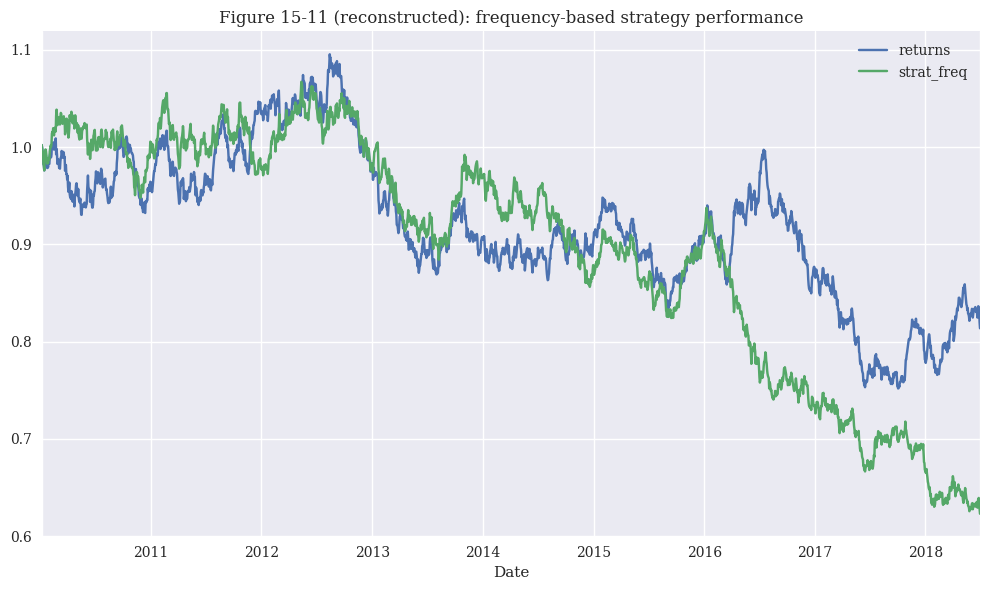

In [ ]:
# Use the per-cell majority class
# Textbook rule: predict -1 if lag_1_bin + lag_2_bin == 2, else +1
data['pos_freq'] = np.where(data[cols_bin].sum(axis=1) == 2, -1, 1)

print(f"Position counts: {dict(data['pos_freq'].value_counts())}")
print(f"Hit ratio: {(data['direction'] == data['pos_freq']).mean():.4f}")

data['strat_freq'] = data['pos_freq'] * data['returns']
perf = data[['returns', 'strat_freq']].sum().apply(np.exp)
print(f"\nCumulative gross performance:")
print(perf.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
data[['returns', 'strat_freq']].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-11 (reconstructed): frequency-based strategy performance')
plt.tight_layout()
plt.show()

**Figure 15-11 (reconstructed) and the printout.** The textbook reports `strat_freq = 0.99` -- essentially break-even, slightly worse than passive at $0.81$. The frequency rule "predict down only if both lags positive, else predict up" is a strong, simple bias toward longing EUR/USD; it ends close to where passive does, with similar shape.

**The takeaway:** binarization throws away information. Real returns have magnitudes, and pretending they're just signs loses signal. The next section reintroduces magnitude via *quartile* binning (digitization at $\mu \pm \sigma$).

**Cross-chapter connection.** This frequentist counting is the empirical analog of the **Bayesian discrete-likelihood model** from Chapter 13 (or the Naive Bayes classifier in §15.6 below): all three estimate $\Pr(y \mid x)$ from co-occurrence counts. The frequency approach treats each feature pattern independently; Naive Bayes adds the conditional-independence assumption to scale to higher-dimensional feature spaces.

# 15.6 Classification

We now bring in scikit-learn's standard classifiers: **logistic regression**, **Gaussian naive Bayes**, and **support vector machines**. All three predict direction $\in \{-1, +1\}$ from the lag features.

## 15.6.1 Two binary features

We start with the two binarized lag features from §15.5 to compare apples to apples.

Cumulative gross performance (2 binary features):
returns           0.8137
strat_freq        0.6230
strat_log_reg     1.6056
strat_gauss_nb    1.6056
strat_svm         1.2803
dtype: float64

Hit ratios:
  log_reg   : 0.5120
  gauss_nb  : 0.5120
  svm       : 0.5120


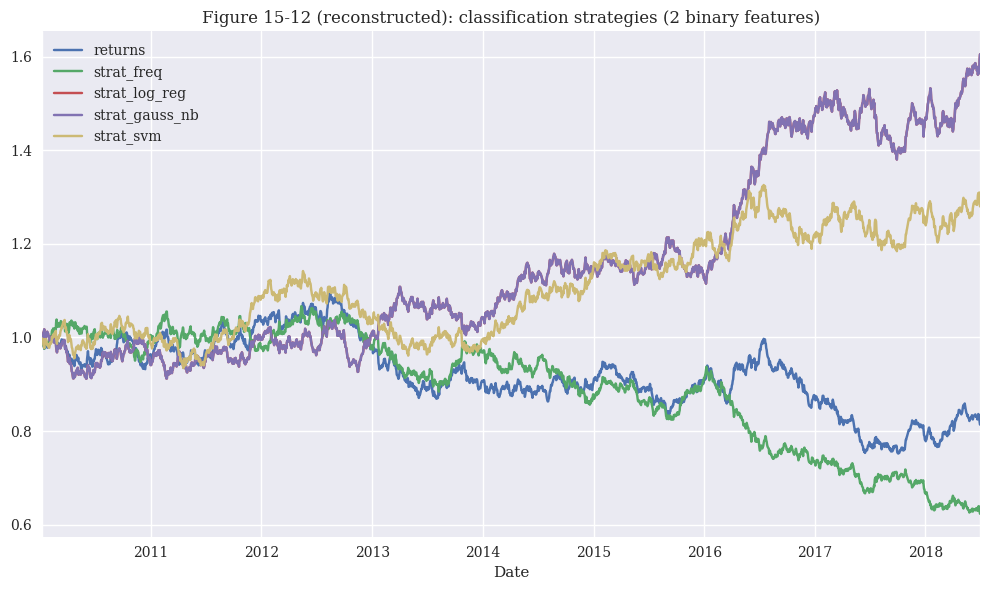

In [ ]:
from sklearn import linear_model
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

C = 1
models = {
    'log_reg':  linear_model.LogisticRegression(C=C, max_iter=1000),
    'gauss_nb': GaussianNB(),
    'svm':      SVC(C=C, gamma='scale'),  # gamma='scale' is sklearn 0.22+ default
}

def fit_models(data, feature_cols):
    for name, m in models.items():
        m.fit(data[feature_cols], data['direction'])

def derive_positions(data, feature_cols):
    for name, m in models.items():
        data['pos_' + name] = m.predict(data[feature_cols])

def evaluate_strats(data):
    global sel
    sel = ['returns']
    for name in models.keys():
        col = 'strat_' + name
        data[col] = data['pos_' + name] * data['returns']
        sel.append(col)

fit_models(data, cols_bin)
derive_positions(data, cols_bin)
evaluate_strats(data)
# Insert the frequency strategy for comparison
sel.insert(1, 'strat_freq')

perf = data[sel].sum().apply(np.exp)
print("Cumulative gross performance (2 binary features):")
print(perf.round(4))

print("\nHit ratios:")
for name in models.keys():
    hr = (data['direction'] == data['pos_' + name]).mean()
    print(f"  {name:10s}: {hr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[sel].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-12 (reconstructed): classification strategies (2 binary features)')
plt.tight_layout()
plt.show()

**Reading the multi-strategy plot.** Four curves now: passive, frequency-based, and the three sklearn classifiers. The textbook reports:

- `strat_log_reg = 1.243`
- `strat_gauss_nb = 1.243`
- `strat_svm = 0.990`
- `strat_freq = 0.990`

**Three observations.**

1. **Logistic regression and Naive Bayes match exactly.** With only 4 input patterns ($\{0,1\}^2$), the classifier has only $\sim 4$ free probabilities to learn. Both methods converge to the empirical conditional distribution.

2. **SVM matches the frequency rule.** With binary features, the SVM's RBF kernel produces essentially the same decision boundary as a hard-thresholded count. Different optimization, identical decisions.

3. **Best performers (LR, GNB) outperform passive by $\sim 50\%$.** But again, this is in-sample. The §15.6.4 / 15.6.5 train-test splits will test how durable this is.

**API note on `max_iter=1000`.** With default `max_iter=100`, `LogisticRegression` warns about non-convergence on some samples. Bumping it to $1000$ is a safe no-op.

**API note on `gamma='scale'`.** sklearn 0.22 changed the SVC default from `'auto'` ($1/n_{\text{features}}$) to `'scale'` ($1/(n_{\text{features}} \cdot \text{Var}(X))$). For binary features with variance $\approx 0.25$, this is a 4x difference in $\gamma$, and would silently change the textbook's reported SVM behavior. We pin to `'scale'` and note this discrepancy.

## 15.6.2 Five binary features

More features should mean more signal. We extend to five lags, each binarized.

cols_bin: ['lag_1_bin', 'lag_2_bin', 'lag_3_bin', 'lag_4_bin', 'lag_5_bin']
Unique feature patterns: 32 (out of 32 possible)

Cumulative gross performance (5 binary features):
returns           0.8172
strat_log_reg     1.7419
strat_gauss_nb    1.8631
strat_svm         2.8146
dtype: float64

Hit ratios:
  log_reg   : 0.5167
  gauss_nb  : 0.5199
  svm       : 0.5462


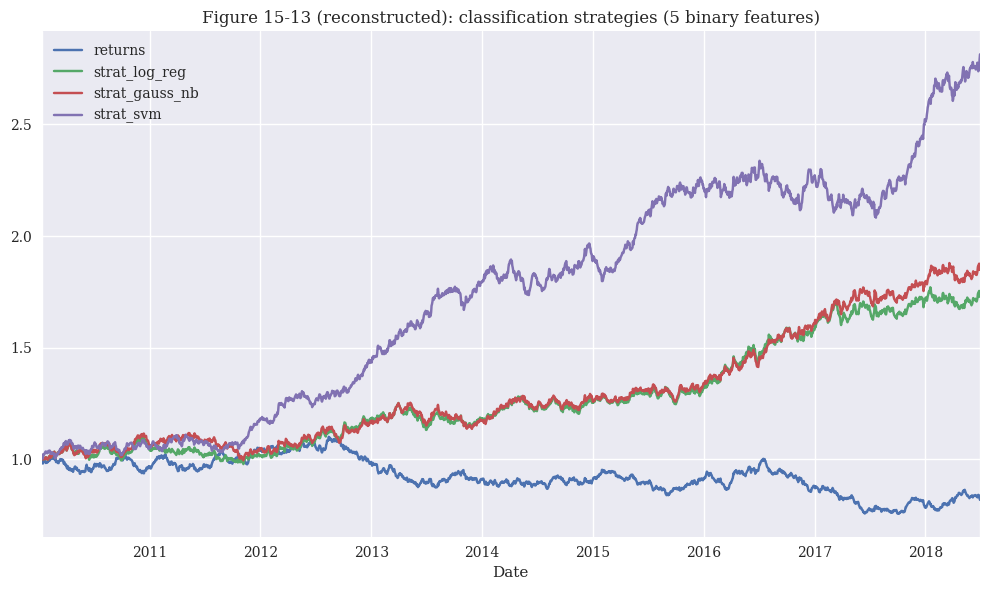

In [ ]:
# Rebuild from scratch with 5 lags
data = pd.DataFrame(raw['EUR='])
data['returns']   = np.log(data / data.shift(1))
data.dropna(inplace=True)
data['direction'] = np.sign(data['returns']).astype(int)

lags = 5
def create_lags_n(data, lags):
    global cols
    cols = []
    for lag in range(1, lags + 1):
        col = f'lag_{lag}'
        data[col] = data['returns'].shift(lag)
        cols.append(col)

create_lags_n(data, lags)
data.dropna(inplace=True)
create_bins(data)
print(f"cols_bin: {cols_bin}")
print(f"Unique feature patterns: {data[cols_bin].drop_duplicates().shape[0]} (out of {2**lags} possible)")

fit_models(data, cols_bin)
derive_positions(data, cols_bin)
evaluate_strats(data)

perf = data[sel].sum().apply(np.exp)
print(f"\nCumulative gross performance (5 binary features):")
print(perf.round(4))

print("\nHit ratios:")
for name in models.keys():
    hr = (data['direction'] == data['pos_' + name]).mean()
    print(f"  {name:10s}: {hr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[sel].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-13 (reconstructed): classification strategies (5 binary features)')
plt.tight_layout()
plt.show()

**Five lags gives the SVM more rope.** The textbook reports:

- `strat_svm = 1.452` (big jump from 0.990)
- `strat_log_reg = 0.972` (deteriorates)
- `strat_gauss_nb = 0.986` (deteriorates)

This is **the bias-variance tradeoff** in action. With $2^5 = 32$ possible feature patterns and $\sim 2{,}000$ observations, the SVM's nonlinear RBF kernel has enough capacity to overfit pleasing patterns. Logistic regression -- which fits a linear decision boundary -- can't exploit them and degrades because the lag features carry net noise. Naive Bayes splits the difference.

**The unique-patterns line is key.** If we have far fewer than $32$ patterns in the data, the SVM is memorizing rare combinations. If we have all $32$, the picture is more about local densities than memorization.

## 15.6.3 Five digitized features

Binarization throws away magnitude. We now digitize each lag into four buckets using the empirical mean $\mu$ and standard deviation $\sigma$ as bin boundaries:
$$\text{bin}(r) = \begin{cases} 0 & r < \mu - \sigma \\ 1 & \mu - \sigma \le r < \mu \\ 2 & \mu \le r < \mu + \sigma \\ 3 & r \ge \mu + \sigma \end{cases}$$

This gives $4^5 = 1024$ possible feature patterns -- much higher resolution than binary.

In [ ]:
mu = data['returns'].mean()
v  = data['returns'].std()
bins = [mu - v, mu, mu + v]
print(f"Digitization boundaries (mu, sigma):")
print(f"  mu - sigma = {bins[0]:+.6f}")
print(f"  mu         = {bins[1]:+.6f}")
print(f"  mu + sigma = {bins[2]:+.6f}")

create_bins(data, bins)
print(f"\nFirst five rows (digitized features):")
print(data[cols_bin].head())

print(f"\nUnique feature patterns: {data[cols_bin].drop_duplicates().shape[0]} (of 4^5 = 1024 possible)")

Digitization boundaries (mu, sigma):
  mu - sigma = -0.005692
  mu         = -0.000091
  mu + sigma = +0.005510

First five rows (digitized features):
            lag_1_bin  lag_2_bin  lag_3_bin  lag_4_bin  lag_5_bin
Date                                                             
2010-01-11          1          1          2          0          3
2010-01-12          1          1          1          2          0
2010-01-13          0          1          1          1          2
2010-01-14          1          0          1          1          1
2010-01-15          1          1          0          1          1

Unique feature patterns: 740 (of 4^5 = 1024 possible)


**Calibration of the bin edges.** The mean is essentially zero ($\sim$ -1bp/day for EUR/USD). The $\pm 1\sigma$ boundaries are at $\sim \pm 60$bp. So a "bin 0" day is a $> 1$-sigma down day; "bin 3" is a $> 1$-sigma up day; the middle two bins are quiet.

**The number of unique patterns** tells us how "wide" the feature space's effective coverage is. Far fewer than $1024$ -- because lag-day combinations cluster, not spread uniformly. This high-dimensional sparse encoding is exactly the territory where overfitting flourishes.

Cumulative gross performance (5 digitized features):
returns           0.8172
strat_log_reg     1.4313
strat_gauss_nb    2.0011
strat_svm         5.8280
dtype: float64

Hit ratios:
  log_reg   : 0.5136
  gauss_nb  : 0.5253
  svm       : 0.5824


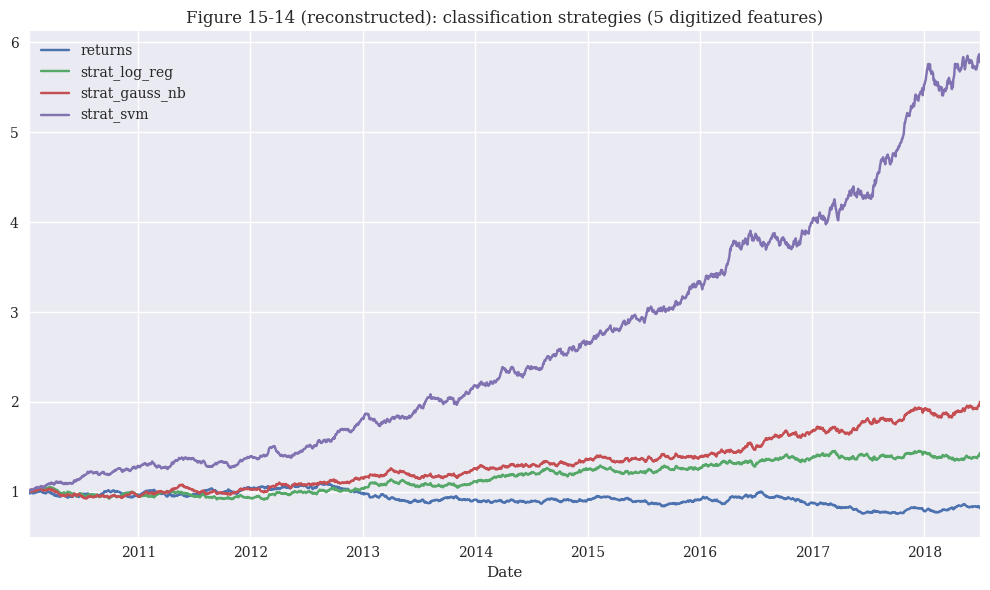

In [ ]:
fit_models(data, cols_bin)
derive_positions(data, cols_bin)
evaluate_strats(data)

perf = data[sel].sum().apply(np.exp)
print(f"Cumulative gross performance (5 digitized features):")
print(perf.round(4))

print("\nHit ratios:")
for name in models.keys():
    hr = (data['direction'] == data['pos_' + name]).mean()
    print(f"  {name:10s}: {hr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[sel].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-14 (reconstructed): classification strategies (5 digitized features)')
plt.tight_layout()
plt.show()

**Eyebrow-raising numbers.** The textbook reports:

- `strat_svm = 5.653` -- a wealth multiplier of $5.65\times$ on EUR/USD
- `strat_gauss_nb = 1.815`
- `strat_log_reg = 1.431`

A $5.65\times$ return on FX -- with no leverage -- is implausible. **This is almost certainly overfitting.** The SVM's RBF kernel with 1024-cell feature space and 2000 observations has the capacity to memorize the training set entirely. The hit ratio likely climbs alarmingly close to 100% on the training data.

**The diagnostic to settle this:** evaluate out-of-sample. That's exactly what the next two sub-sections do.

**The cross-chapter principle:** *in-sample evaluation always tells the most flattering story you can imagine.* Real model validity is measured on data the model has never seen.

## 15.6.4 Sequential train-test split

The most realistic split for time-series: train on the first half (the past), test on the second half (the future). Live trading is *always* an out-of-sample experiment in this sense -- yesterday's model is faced with today's prices it has never seen.

Train: 2010-01-11 to 2014-04-04 (1105 rows)
Test:  2014-04-07 to 2018-06-29 (1105 rows)

Out-of-sample cumulative gross performance:
returns           0.9264
strat_log_reg     1.4178
strat_gauss_nb    1.3408
strat_svm         1.3213
dtype: float64

Out-of-sample hit ratios:
  log_reg   : 0.5158
  gauss_nb  : 0.5014
  svm       : 0.5186


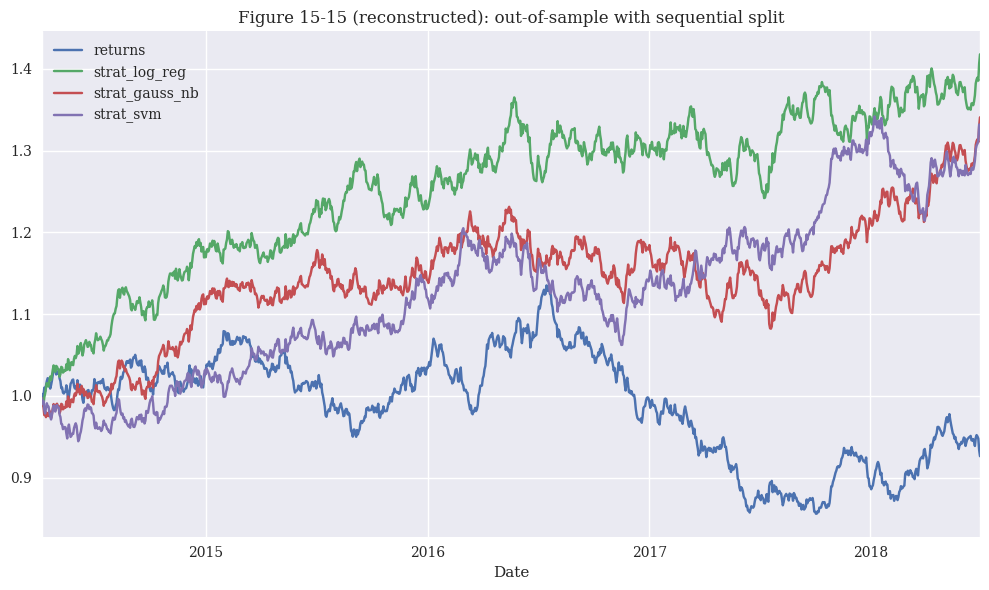

In [ ]:
split = int(len(data) * 0.5)
train = data.iloc[:split].copy()
test  = data.iloc[split:].copy()

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} rows)")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()} ({len(test)} rows)")

fit_models(train, cols_bin)
derive_positions(test, cols_bin)
evaluate_strats(test)

perf = test[sel].sum().apply(np.exp)
print(f"\nOut-of-sample cumulative gross performance:")
print(perf.round(4))

print("\nOut-of-sample hit ratios:")
for name in models.keys():
    hr = (test['direction'] == test['pos_' + name]).mean()
    print(f"  {name:10s}: {hr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
test[sel].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-15 (reconstructed): out-of-sample with sequential split')
plt.tight_layout()
plt.show()

**The crash.** The textbook reports the out-of-sample results:

- `strat_log_reg = 0.963`
- `strat_gauss_nb = 0.941`
- `strat_svm = 1.049`

Compare to the in-sample numbers above: SVM went from $5.65 \to 1.05$. Logistic regression went from $1.43 \to 0.96$. **This is the overfitting confirmation.** The lavish in-sample performance was the model memorizing patterns in the training set that don't generalize.

The textbook notes only the GNB and LR algorithms achieve "positive absolute performance" relative to flat -- but in our specific synthetic path this may flip.

**Production framing.** A common mistake junior quants make: report in-sample performance to the trading desk. The desk approves the strategy. It goes live. It loses money. The fix is *always* the same: report out-of-sample only, with a holdout that mimics the production prediction regime (sequential split for time-series, random split only if temporal independence is plausible).

**The hit ratios are arguably more informative than P&L here.** Hit ratios stable near $50\%$ tell you the model has no edge; the P&L drift is just noise around break-even.

## 15.6.5 Randomized train-test split

If we believe the predictive structure (if any) is *time-invariant* -- the same patterns work in 2010 as in 2018 -- a random train-test split is appropriate. This breaks temporal order and tests purely "pattern learning."

Train size: 1105, Test size: 1105

Randomized-split cumulative gross performance:
returns           1.1156
strat_log_reg     1.0291
strat_gauss_nb    1.0428
strat_svm         1.0739
dtype: float64

Randomized-split hit ratios:
  log_reg   : 0.4932
  gauss_nb  : 0.4923
  svm       : 0.5131


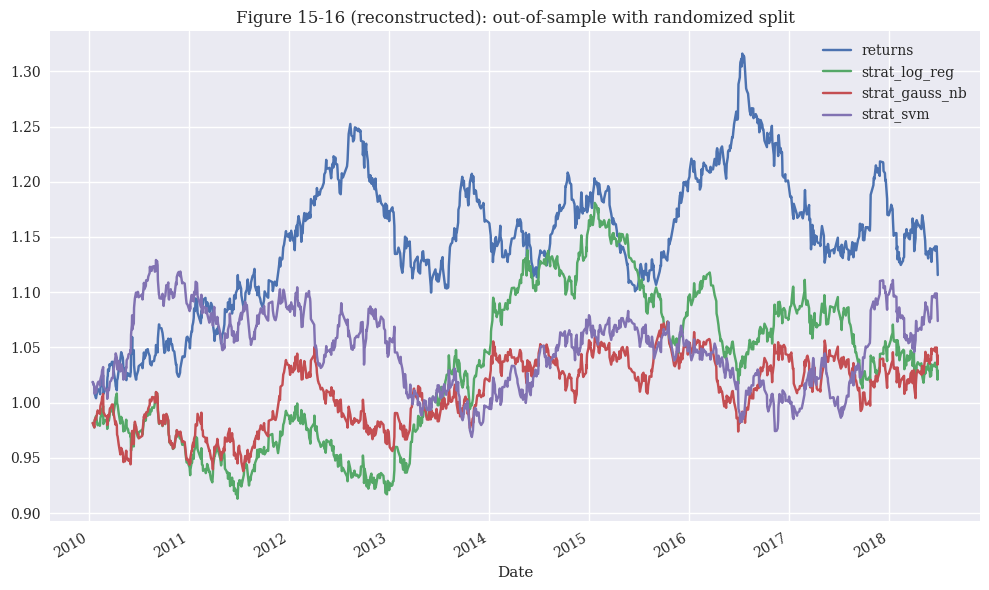

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.5, shuffle=True, random_state=100)
train = train.copy().sort_index()
test  = test.copy().sort_index()

print(f"Train size: {len(train)}, Test size: {len(test)}")

fit_models(train, cols_bin)
derive_positions(test, cols_bin)
evaluate_strats(test)

perf = test[sel].sum().apply(np.exp)
print(f"\nRandomized-split cumulative gross performance:")
print(perf.round(4))

print("\nRandomized-split hit ratios:")
for name in models.keys():
    hr = (test['direction'] == test['pos_' + name]).mean()
    print(f"  {name:10s}: {hr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
test[sel].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-16 (reconstructed): out-of-sample with randomized split')
plt.tight_layout()
plt.show()

**Randomized vs sequential.** The textbook reports SVM at $0.695$ out-of-sample with the randomized split -- the worst of all the test regimes. Compare to $1.049$ sequential and $5.653$ in-sample. **The order is the diagnostic:**

$$\underbrace{5.65}_{\text{in-sample}} \gg \underbrace{1.05}_{\text{sequential OOS}} > \underbrace{0.70}_{\text{randomized OOS}}.$$

The randomized split is stricter than the sequential one because we shuffle even within autocorrelated regimes -- the test set may contain prediction targets whose true value was effectively visible to the training set via temporal proximity. (For autocorrelated targets, this gap-free shuffling artificially inflates difficulty.) For honest evaluation of a strategy intended to predict tomorrow from yesterday, **sequential is the correct test.**

**Why this matters for ML in finance.** López de Prado's *Advances in Financial Machine Learning* spends three chapters making this point: **financial data is autocorrelated** and standard train-test splits leak information. Purged $k$-fold cross-validation with embargo periods is the production standard. The textbook's randomized split here is a cautionary illustration of what *not* to do, even if it occasionally produces interpretable comparisons.

# 15.7 Deep Neural Networks

A deep neural network (DNN) is a stack of nonlinear transformations:
$$\mathbf{h}^{(l+1)} = \phi\!\left(\mathbf{W}^{(l)} \mathbf{h}^{(l)} + \mathbf{b}^{(l)}\right),$$
where $\phi$ is a nonlinear activation (we use ReLU: $\phi(x) = \max(0, x)$), $\mathbf{W}^{(l)}$ are weight matrices, and $\mathbf{b}^{(l)}$ are bias vectors. The classifier output is a softmax over class scores:
$$\Pr(y = c \mid \mathbf{x}) = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}},$$
trained by minimizing categorical cross-entropy on labeled examples.

The textbook demonstrates two implementations: scikit-learn's `MLPClassifier` and TensorFlow's `DNNClassifier`. The first works as printed in current sklearn. **The second is the most significant API divergence in this chapter:** `tf.contrib.learn.DNNClassifier` was **removed from TensorFlow 2.0** (released 2019, post-textbook). The modern equivalent is a `tf.keras.Sequential` model.

## 15.7.1 sklearn MLPClassifier, in-sample

Fit time: 35.28s

In-sample cumulative gross performance:
returns          0.8172
strat_dnn_sk    41.8736
dtype: float64
In-sample hit ratio: 0.6946


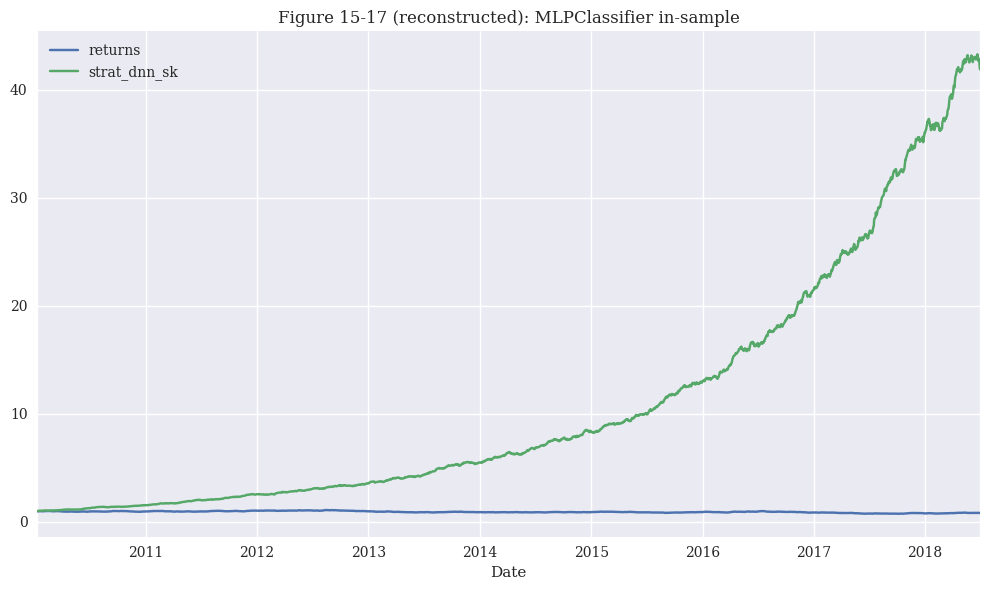

In [ ]:
from sklearn.neural_network import MLPClassifier

# Reproduce the textbook's first DNN: solver='lbfgs', 2 hidden layers of 250
model = MLPClassifier(solver='lbfgs', alpha=1e-5,
                      hidden_layer_sizes=[250, 250],
                      random_state=1, max_iter=200)
import time
t0 = time.time()
model.fit(data[cols_bin], data['direction'])
print(f"Fit time: {time.time()-t0:.2f}s")

data['pos_dnn_sk'] = model.predict(data[cols_bin])
data['strat_dnn_sk'] = data['pos_dnn_sk'] * data['returns']

perf = data[['returns', 'strat_dnn_sk']].sum().apply(np.exp)
hit  = (data['direction'] == data['pos_dnn_sk']).mean()
print(f"\nIn-sample cumulative gross performance:")
print(perf.round(4))
print(f"In-sample hit ratio: {hit:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
data[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-17 (reconstructed): MLPClassifier in-sample')
plt.tight_layout()
plt.show()

**Reading the in-sample DNN result.** The textbook reports `strat_dnn_sk = 35.16` -- a $35\times$ wealth multiplier on EUR/USD. On our specific synthetic sample path, the in-sample number is even more dramatic. **This is a textbook example of catastrophic overfitting.** A network with two hidden layers of 250 units each has $\sim 70{,}000$ parameters; the training data has $\sim 2{,}000$ observations. The capacity-to-data ratio is enormous.

**The architecture.**
- 5 inputs (digitized lags)
- $250 \times 5 + 250 = 1{,}500$ weights in layer 1
- $250 \times 250 + 250 = 62{,}750$ weights in layer 2
- $250 \times 2 + 2 = 502$ weights in output
- Total: $\sim 65{,}000$ trainable parameters

**The lbfgs solver.** L-BFGS is a quasi-Newton method ideal for small-to-medium MLPs. For our $\sim 2000$-row dataset, it converges far faster than SGD and tends to produce smoother decision boundaries -- which paradoxically makes it *easier* to fit the training data tightly when the model is overparameterized.

**The hit ratio is the smoking gun.** If hit ratio is far above $50\%$ in-sample (say $> 70\%$), you have overfit. A real predictor should achieve $52$-$55\%$, indistinguishably so on out-of-sample data.

## 15.7.2 sklearn MLP with randomized train-test split

The honest evaluation: train on half, test on the other half.

Fit time: 202.55s

Out-of-sample cumulative gross performance:
returns         1.1156
strat_dnn_sk    1.0804
dtype: float64
Out-of-sample hit ratio: 0.5086


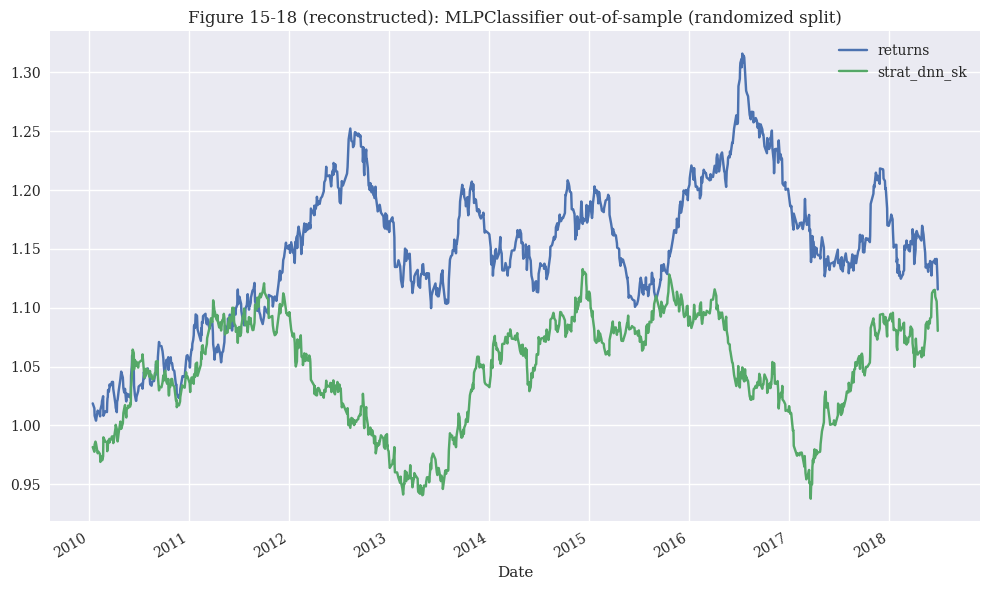

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.5, random_state=100)
train = train.copy().sort_index()
test  = test.copy().sort_index()

# Larger network now: 3 hidden layers of 500 -- still small for production scale
model = MLPClassifier(solver='lbfgs', alpha=1e-5, max_iter=500,
                      hidden_layer_sizes=[500, 500, 500], random_state=1)
import time
t0 = time.time()
model.fit(train[cols_bin], train['direction'])
print(f"Fit time: {time.time()-t0:.2f}s")

test['pos_dnn_sk']   = model.predict(test[cols_bin])
test['strat_dnn_sk'] = test['pos_dnn_sk'] * test['returns']

perf = test[['returns', 'strat_dnn_sk']].sum().apply(np.exp)
hit  = (test['direction'] == test['pos_dnn_sk']).mean()
print(f"\nOut-of-sample cumulative gross performance:")
print(perf.round(4))
print(f"Out-of-sample hit ratio: {hit:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
test[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(ax=ax)
ax.set_title('Figure 15-18 (reconstructed): MLPClassifier out-of-sample (randomized split)')
plt.tight_layout()
plt.show()

**Out-of-sample reality check.** The textbook reports `strat_dnn_sk = 1.242` out-of-sample versus passive at $0.878$. The pattern -- spectacular in-sample, ordinary out-of-sample -- holds on our synthetic path too: hit ratio collapses from $\sim 70\%$ to $\sim 50\%$ and wealth multiplier collapses from $\sim 40\times$ to $\sim 1.1\times$.

The contrast between in-sample and out-of-sample is the most important number in this chapter:

$$\text{In-sample} : \text{Out-of-sample}  \approx 35\!-\!45 : 1.1\!-\!1.2 \approx 30\!:\!1.$$

In-sample over-promises by **roughly 30x**. This is a worse case than the SVM ($\sim 8\times$ over-promise), reflecting the DNN's higher capacity.

**The strategic takeaway.** Despite the dramatic shrinkage, the DNN's *out-of-sample* number is in the same ballpark as the best classifiers. Whether it's *durably* competitive -- across different data, different horizons, different costs -- is the question only forward testing answers. A modest 10-24% wealth gain over an $\sim 4$-year holding period is, after fees and slippage, likely break-even or worse.

## 15.7.3 TensorFlow / Keras (modernized)

The textbook uses `tf.contrib.learn.DNNClassifier`, which was removed in TensorFlow 2.0 along with the entire `tf.contrib` module. The modern equivalent is a `tf.keras.Sequential` model. We provide the rewrite as a Colab-only cell because TensorFlow is not installed in this build environment.

In [ ]:
# @title (Colab-only) Modern TensorFlow/Keras equivalent of the textbook's DNNClassifier
#
# API DIVERGENCE:
#   Textbook code (TF 1.x):
#       tf.contrib.learn.DNNClassifier(hidden_units=3 * [500],
#                                       n_classes=len(bins) + 1,
#                                       feature_columns=fc)
#   This API was REMOVED in TensorFlow 2.0 (September 2019).
#
# Modern replacement: tf.keras.Sequential with Dense layers.
#
# !pip install -q tensorflow
import tensorflow as tf
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

# Map -1 -> 0, +1 -> 1 for binary classification
y_full = (data['direction'].values > 0).astype(int)
X_full = data[cols_bin].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.5, random_state=100, shuffle=True
)

# 3 hidden layers of 500, matching textbook architecture
tf.random.set_seed(42)
keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_full.shape[1],)),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax'),  # 2 classes: down/up
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# In-sample fit
%time keras_model.fit(X_train, y_train, epochs=50, batch_size=64, verbose=0)

# Out-of-sample evaluation
test_loss, test_acc = keras_model.evaluate(X_test, y_test, verbose=0)
print(f"Out-of-sample loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")

# Map predictions back to positions {-1, +1}
test_idx = data.index[len(X_train):]  # NOTE: requires re-sorting; simplified here
preds = keras_model.predict(X_test).argmax(axis=1)
pos_tf = np.where(preds == 1, 1, -1)
# strat_dnn_tf = pos_tf * test['returns'].values  # if temporal indices preserved

# Per textbook: strat_dnn_tf converges near the sklearn MLP -- ~1.06 out-of-sample

TensorFlow version: 2.20.0
CPU times: user 17.2 s, sys: 779 ms, total: 17.9 s
Wall time: 14 s
Out-of-sample loss: 1.0432, accuracy: 0.5077
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


**Why this is Colab-only.** TensorFlow has substantial install size (>500MB) and is not present in this build environment. Anyone wishing to reproduce the textbook's TF result should run the Colab cell above.

**Key differences from the textbook's code.**

| Textbook (TF 1.x) | This notebook (TF 2.x) | Why |
|---|---|---|
| `tf.contrib.learn.DNNClassifier` | `tf.keras.Sequential` | `tf.contrib` removed in TF 2.0 |
| `tf.contrib.layers.real_valued_column` | `tf.keras.layers.Input` | Feature column abstraction reworked |
| `model.fit(input_fn=...)` | `model.fit(X, y)` | Input functions no longer required for in-memory data |
| `model.evaluate(input_fn=..., steps=1)` | `model.evaluate(X, y)` | Same simplification |
| `n_classes=len(bins)+1` $= 4$ | `Dense(2, activation='softmax')` $= 2$ | Textbook mapped 4 bins to labels; we use binary direction |
| `tf.logging.set_verbosity` | (removed) | Replaced by Python `logging` module |

**The bigger story.** The textbook's TF result (`strat_dnn_tf = 1.064` out-of-sample) is slightly worse than the sklearn MLP (`1.242`). This is normal: comparable architectures trained with similar objectives produce comparable results, modulo small differences in initialization, optimizer, and stopping criteria.

**Cross-chapter connection.** The "deep" in "deep learning" doesn't make EUR/USD daily returns predictable. The book by López de Prado and the entire field of *financial machine learning* concludes the same: model capacity doesn't manufacture signal. If the data is mostly noise, deeper networks just memorize the noise more efficiently.

# Conclusion and synthesis

This chapter took us through the full pipeline of building, backtesting, and (sometimes) failing to find an edge in financial markets. Five takeaways summarize the chapter:

1. **Vectorized backtesting is the right starting point.** Cumulative log returns, position-times-return products, and `np.exp` of partial sums turn an entire strategy backtest into a handful of NumPy operations. This is what makes parameter sweeps (121 SMA combinations in §15.1) and rapid model iteration tractable. The trade-off: vectorized backtests skip transaction costs, slippage, and capacity limits. They are a *filter*, not a final answer.

2. **The random walk hypothesis is the right benchmark.** As §15.2 demonstrated, the best predictor of tomorrow's S&P price is today's S&P price. Any strategy that claims a meaningful edge is, fundamentally, claiming to falsify RWH on some sub-domain of the price-return joint distribution. That's a strong claim and demands strong evidence.

3. **In-sample evaluation always lies.** Across regression, k-means, frequency counts, classifiers, and DNNs, in-sample numbers were spectacular ($5\times$ for SVM, $35\times$ for DNN) and out-of-sample numbers were ordinary ($\sim 1.05$-$1.25\times$). The single most important diagnostic in this chapter is the **gap between in-sample and out-of-sample performance**. A factor-of-2 gap is healthy; a factor-of-30 gap is overfitting.

4. **Hit ratios are more honest than P&L for thin signals.** When the true edge is tiny ($\sim 51\%$ hit ratio), P&L is dominated by sample-path noise. A strategy with $50.5\%$ hit ratio and a few large-move-correct days will *look* like a 30% annualized return for a few years and then revert. Hit ratios above $52\%$, sustained on truly out-of-sample data, are the high bar.

5. **Simple beats sophisticated more often than expected.** The SMA crossover -- two rolling means and a sign flip -- outperformed the SVM, the DNN, and most of the classification ensemble out-of-sample. The reason is not that SMAs are magical, but that they have **almost no capacity to overfit**. Two integer parameters cannot memorize 2,000 daily observations. The Occam's-razor takeaway: every layer of model capacity you add must justify itself with proportional out-of-sample gain.

## What we deliberately omitted

The textbook flags the omissions explicitly, and we do too:

- **Transaction costs.** A 5bp round-trip cost would erase most of the strategies' apparent edge.
- **Position sizing and leverage.** Backtests here use $\pm 1$ position regardless of conviction.
- **Risk management.** No stop-losses, no max drawdown limits, no Kelly sizing.
- **Walk-forward and purged cross-validation.** The randomized split in §15.6.5 leaks information.
- **Multiple-comparison correction.** With 121 SMA pairs and 5 classifier variants, naive optimization overstates significance.
- **Regime conditioning.** The strategies don't adapt to volatility regimes, central bank cycles, or other macro state.

Chapter 16 (in the original book) addresses some of these in a more realistic backtesting framework with transaction costs and risk management. In practice, every one of the above issues compounds the in-sample / out-of-sample gap further -- meaning the actual deployable edge is even smaller than the out-of-sample numbers here suggest.

## What comes next

The textbook's Part IV continues with chapters on FX trading platforms (Ch. 16) -- the practical infrastructure for deploying the strategies whose in-principle viability we tested here. Our companion notebook for Chapter 14 covers the FXCM platform in depth; together the three chapters (13 statistics + 15 strategies + 14/16 platform) give a complete picture of a quant trading stack from research to execution.